# Exploração inicial — case Vértice / MIPO\n\nNotebook organizado para publicação. Os caminhos de dados são relativos a `../data/`. As bases brutas não acompanham o repositório público. Resultados representam evidência histórica ou estimativa; associação não implica causalidade e exposição não equivale a perda comprovada.

# 🔬 AI Consulting Lab — Projeto Vértice
## Análise Exploratória de Dados (EDA)

**Cliente:** Vértice Retail — marca digital de moda, beleza e lifestyle  
**Missão:** Recuperar margem e produtividade usando dados e IA  
**Pergunta central:** *Como podemos usar dados e IA para melhorar rentabilidade, eficiência operacional e qualidade da tomada de decisão nos próximos 90 dias?*

---

### Estrutura da Análise

| # | Seção | Objetivo |
|---|-------|----------|
| 1 | Setup & Carga | Importar bibliotecas e carregar os 5 datasets |
| 2 | Visão Geral | Estrutura, tipos, missing values, estatísticas descritivas |
| 3 | Análise de Vendas & Margem | Onde a margem se deteriora — por produto, categoria, canal ou período? |
| 4 | Análise de Marketing & Canais | Quais canais trazem crescimento sustentável vs. apenas volume? |
| 5 | Análise de Clientes & Segmentação | Quais perfis concentram valor, risco de churn ou potencial de retenção? |
| 6 | Análise de Atendimento | Quais temas se repetem, quais exigem prioridade, quais podem ser automatizados? |
| 7 | Análise de Estoque & Operações | Qual o impacto financeiro de rupturas e problemas operacionais? |
| 8 | Cruzamento entre Datasets | Análises integradas multi-tabela |
| 9 | Síntese de Hipóteses | Hipóteses validadas, refutadas e novas descobertas |
| 10 | Próximos Passos | Recomendações para solução com IA |


---
## 1. 📦 Setup & Carga de Dados


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

# Paleta personalizada para o projeto
COLORS = {
    'purple': '#9B14C4',
    'blue': '#3947F3',
    'green': '#3D6B00',
    'orange': '#FF9800',
    'red': '#FF6B6B',
    'dark': '#1A1D24',
    'gray': '#5A5F6A'
}

print("✅ Bibliotecas carregadas com sucesso!")


✅ Bibliotecas carregadas com sucesso!


In [2]:
# Carregar todos os datasets
vendas = pd.read_csv('data/vendas.csv', encoding='utf-8-sig')
marketing = pd.read_csv('data/marketing.csv', encoding='utf-8-sig')
clientes = pd.read_csv('data/clientes.csv', encoding='utf-8-sig')
atendimento = pd.read_csv('data/atendimento.csv', encoding='utf-8-sig')
estoque = pd.read_csv('data/estoque.csv', encoding='utf-8-sig')

# Converter datas. errors='coerce' permite identificar linhas malformadas antes da exclusão.
vendas['data_pedido'] = pd.to_datetime(vendas['data_pedido'], errors='coerce')
marketing['data_inicio'] = pd.to_datetime(marketing['data_inicio'], errors='coerce')
marketing['data_fim'] = pd.to_datetime(marketing['data_fim'], errors='coerce')
clientes['data_nascimento'] = pd.to_datetime(clientes['data_nascimento'], errors='coerce')
clientes['data_cadastro'] = pd.to_datetime(clientes['data_cadastro'], errors='coerce')
atendimento['data_abertura'] = pd.to_datetime(atendimento['data_abertura'], errors='coerce')
atendimento['data_fechamento'] = pd.to_datetime(atendimento['data_fechamento'], errors='coerce')
estoque['data_ultima_entrada'] = pd.to_datetime(estoque['data_ultima_entrada'], errors='coerce')

# Converter 'devolvido' sem transformar valor inválido em 'não devolvido'.
vendas['devolvido'] = (
    vendas['devolvido'].astype(str).str.strip().str.lower()
    .map({'true': 1, 'false': 0})
)

# Excluir apenas linhas isoladas sem os campos mínimos para análise e manter a contagem auditável.
campos_vendas = [
    'order_id', 'customer_id', 'sku_id', 'data_pedido', 'canal', 'categoria',
    'quantidade', 'receita_bruta', 'desconto_reais', 'receita_liquida',
    'custo_produto', 'custo_frete', 'margem_contribuicao', 'devolvido'
]
campos_atendimento = [
    'ticket_id', 'customer_id', 'order_id', 'data_abertura', 'categoria_problema',
    'status_atendimento', 'texto_cliente', 'nota_csat',
    'tempo_primeira_resposta_minutos', 'custo_operacional_ticket'
]
vendas_invalidas = vendas[campos_vendas].isna().any(axis=1)
atendimento_invalido = atendimento[campos_atendimento].isna().any(axis=1)
vendas = vendas.loc[~vendas_invalidas].copy()
atendimento = atendimento.loc[~atendimento_invalido].copy()
vendas['devolvido'] = vendas['devolvido'].astype(int)

datasets = {
    'Vendas': vendas,
    'Marketing': marketing,
    'Clientes': clientes,
    'Atendimento': atendimento,
    'Estoque': estoque
}

print('📊 Datasets carregados:')
for nome, df in datasets.items():
    print(f'   {nome:15s} → {df.shape[0]:>6,} linhas × {df.shape[1]:>2} colunas')
print(f'\n⚠️ Linhas incompletas excluídas: vendas={vendas_invalidas.sum()}, atendimento={atendimento_invalido.sum()}')

📊 Datasets carregados:
   Vendas          → 27,758 linhas × 20 colunas
   Marketing       →  3,500 linhas × 15 colunas
   Clientes        → 15,000 linhas × 14 colunas
   Atendimento     → 35,840 linhas × 12 colunas
   Estoque         →  5,000 linhas × 16 colunas

⚠️ Linhas incompletas excluídas: vendas=1, atendimento=1


---
## 2. 🔍 Visão Geral dos Dados

Análise inicial da qualidade, completude e características de cada dataset.


In [3]:
# Resumo de missing values e tipos
for nome, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"📋 {nome.upper()}")
    print(f"{'='*60}")
    
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    
    info_df = pd.DataFrame({
        'Tipo': df.dtypes,
        'Não-Nulos': df.notnull().sum(),
        'Nulos': missing,
        '% Nulos': missing_pct,
        'Únicos': df.nunique()
    })
    
    display(info_df)



📋 VENDAS


,Tipo,Não-Nulos,Nulos,% Nulos,Únicos
order_id,str,27758,0,0.0,27758
customer_id,str,27758,0,0.0,346
sku_id,str,27758,0,0.0,4918
data_pedido,datetime64[us],27758,0,0.0,27747
canal,str,27758,0,0.0,7
categoria,str,27758,0,0.0,4
produto,str,27758,0,0.0,3417
quantidade,float64,27758,0,0.0,6
preco_unitario,float64,27758,0,0.0,19176
receita_bruta,float64,27758,0,0.0,23963



📋 MARKETING


,Tipo,Não-Nulos,Nulos,% Nulos,Únicos
campanha_id,str,3500,0,0.0,3500
nome_campanha,str,3500,0,0.0,936
canal,str,3500,0,0.0,7
categoria_foco,str,3500,0,0.0,5
data_inicio,datetime64[us],3500,0,0.0,980
data_fim,datetime64[us],3500,0,0.0,983
investimento_reais,float64,3500,0,0.0,3499
impressoes,int64,3500,0,0.0,3500
cliques,int64,3500,0,0.0,3491
conversoes,int64,3500,0,0.0,3391



📋 CLIENTES


,Tipo,Não-Nulos,Nulos,% Nulos,Únicos
customer_id,str,15000,0,0.0,15000
nome_completo,str,15000,0,0.0,12654
data_nascimento,datetime64[us],15000,0,0.0,6420
genero,str,15000,0,0.0,4
estado,str,15000,0,0.0,27
cidade,str,15000,0,0.0,137
nivel_fidelidade,str,15000,0,0.0,4
data_cadastro,datetime64[us],15000,0,0.0,2016
opt_in_newsletter,bool,15000,0,0.0,2
dispositivo_principal,str,15000,0,0.0,3



📋 ATENDIMENTO


,Tipo,Não-Nulos,Nulos,% Nulos,Únicos
ticket_id,str,35840,0,0.0,35840
customer_id,str,35840,0,0.0,445
order_id,str,35840,0,0.0,28589
data_abertura,datetime64[us],35840,0,0.0,35830
data_fechamento,datetime64[us],35840,0,0.0,26863
canal_entrada,str,35840,0,0.0,5
categoria_problema,str,35840,0,0.0,6
status_atendimento,str,35840,0,0.0,4
texto_cliente,str,35840,0,0.0,30
nota_csat,float64,35840,0,0.0,5



📋 ESTOQUE


,Tipo,Não-Nulos,Nulos,% Nulos,Únicos
sku_id,str,5000,0,0.0,5000
nome_produto,str,5000,0,0.0,3450
categoria,str,5000,0,0.0,4
subcategoria,str,5000,0,0.0,48
fornecedor_id,str,5000,0,0.0,100
lead_time_reposicao,int64,5000,0,0.0,27
custo_unitario,float64,5000,0,0.0,4708
preco_venda_sugerido,float64,5000,0,0.0,4897
estoque_fisico,int64,5000,0,0.0,925
estoque_reservado,int64,5000,0,0.0,264


In [4]:
# Estatísticas descritivas das variáveis numéricas de cada dataset
for nome, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"📊 Estatísticas Descritivas — {nome.upper()}")
    print(f"{'='*60}")
    display(df.describe().round(2))



📊 Estatísticas Descritivas — VENDAS


,data_pedido,quantidade,preco_unitario,receita_bruta,desconto_reais,receita_liquida,custo_produto,custo_frete,margem_contribuicao,tempo_entrega_real,devolvido
count,27758,27758.00,27758.00,27758.00,27758.00,27758.00,27758.00,27758.00,27758.00,27758.00,27758.00
mean,2023-07-27 04:00:41.558073,3.51,210.90,739.47,58.97,680.50,298.24,12.26,370.00,8.30,0.15
min,2023-01-01 00:05:25,1.00,39.02,39.34,0.00,28.16,13.97,0.00,-49.27,1.00,0.00
25%,2023-04-21 16:52:50,2.00,127.46,312.76,0.00,284.23,123.30,0.00,140.34,5.00,0.00
50%,2023-07-27 18:27:16.500000,4.00,195.58,592.02,0.00,540.40,234.12,0.00,289.32,8.00,0.00
75%,2023-11-14 08:27:21.250000,5.00,268.84,1017.62,65.70,934.27,404.18,23.62,519.46,12.00,0.00
max,2024-01-26 10:53:49,6.00,837.06,5004.90,1784.98,5004.90,2372.40,60.00,3130.02,18.00,1.00
std,NaN,1.70,112.49,565.28,122.85,533.70,239.90,18.51,317.85,4.33,0.36



📊 Estatísticas Descritivas — MARKETING


,data_inicio,data_fim,investimento_reais,impressoes,cliques,conversoes,roas,receita_gerada,cac
count,3500,3500,3500.00,3500.00,3500.00,3500.00,3500.00,3500.00,3500.00
mean,2024-07-02 14:12:53.485714,2024-11-13 14:38:48.685714,60118.38,14461952.05,496461.66,32939.56,4.14,251036.77,4.35
min,2023-01-01 00:00:00,2023-01-16 00:00:00,206.17,35667.00,907.00,32.00,0.53,511.30,0.37
25%,2023-10-16 00:00:00,2024-02-05 00:00:00,31303.54,6186184.50,161425.75,7715.75,2.67,96652.46,1.32
50%,2024-07-03 00:00:00,2024-12-03 00:00:00,60139.18,12240976.50,368427.00,20152.00,3.63,199289.68,2.41
75%,2025-03-27 00:00:00,2025-10-19 00:00:00,89180.83,21167993.75,695209.50,44989.75,4.75,336453.70,4.89
max,2025-12-28 00:00:00,2025-12-31 00:00:00,119948.78,46719507.00,2642362.00,285864.00,14.94,1712999.32,82.33
std,NaN,NaN,34139.94,10381139.59,446805.90,36928.90,2.46,225215.34,5.92



📊 Estatísticas Descritivas — CLIENTES


,data_nascimento,data_cadastro,renda_estimada,total_pedidos_historico,ltv_acumulado
count,15000,15000,15000.00,15000.00,15000.00
mean,1996-01-23 00:28:13.440000,2022-12-29 21:34:27.840000,13783.38,18.59,9272.84
min,1985-01-01 00:00:00,2020-01-01 00:00:00,2502.62,1.00,133.55
25%,1990-07-06 00:00:00,2021-06-26 00:00:00,8077.70,5.00,2128.33
50%,1996-01-17 12:00:00,2023-01-03 00:00:00,13922.22,9.00,4773.16
75%,2001-08-20 00:00:00,2024-06-28 00:00:00,19435.84,25.00,11479.69
max,2006-12-27 00:00:00,2025-12-28 00:00:00,24997.71,120.00,118316.70
std,NaN,NaN,6516.30,21.61,12151.62



📊 Estatísticas Descritivas — ATENDIMENTO


,data_abertura,data_fechamento,nota_csat,tempo_primeira_resposta_minutos,custo_operacional_ticket
count,35840,35840,35840.00,35840.00,35840.00
mean,2024-07-17 00:55:28.343499,2024-11-27 12:18:16.787416,3.24,135.41,14.85
min,2023-01-01 07:54:47,2023-01-01 17:54:05,1.00,0.00,2.00
25%,2023-11-05 16:27:16.500000,2024-01-01 05:08:58,3.00,3.00,15.00
50%,2024-07-19 09:29:43,2024-12-28 11:31:23,3.00,11.00,15.00
75%,2025-04-07 11:20:16.750000,2025-12-31 23:59:00,4.00,189.00,15.00
max,2025-12-31 21:11:32,2025-12-31 23:59:00,5.00,1440.00,45.00
std,NaN,NaN,1.10,254.17,10.36



📊 Estatísticas Descritivas — ESTOQUE


,lead_time_reposicao,custo_unitario,preco_venda_sugerido,estoque_fisico,estoque_reservado,estoque_disponivel,ponto_pedido,data_ultima_entrada,shelf_life_dias,volume_m3
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000,5000.00,5000.00
mean,26.98,207.43,499.90,334.32,50.30,284.02,81.05,2024-06-22 06:13:49.440000,448.35,0.25
min,5.00,20.02,33.24,0.00,0.00,0.00,10.00,2023-01-01 00:00:00,180.00,0.00
25%,9.00,109.77,255.55,150.00,11.00,125.00,47.00,2023-09-17 00:00:00,448.00,0.13
50%,14.00,206.64,470.10,302.00,34.00,256.00,82.00,2024-06-17 00:00:00,448.00,0.25
75%,50.00,303.17,713.37,456.00,73.00,391.00,116.00,2025-03-25 00:00:00,448.00,0.37
max,60.00,399.90,1276.55,1200.00,352.00,1183.00,150.00,2025-12-28 00:00:00,730.00,0.50
std,21.14,110.23,289.22,242.07,51.99,207.64,40.36,NaN,88.00,0.14


In [5]:
# Análise de valores únicos em variáveis categóricas chave
print("🏷️ VENDAS — Categorias e Canais:")
print(f"   Canais de venda:   {vendas['canal'].nunique()} → {vendas['canal'].unique().tolist()}")
print(f"   Categorias:        {vendas['categoria'].nunique()} → {vendas['categoria'].unique().tolist()}")
print(f"   Métodos pagamento: {vendas['metodo_pagamento'].nunique()} → {vendas['metodo_pagamento'].unique().tolist()}")
print(f"   Status pagamento:  {vendas['status_pagamento'].unique().tolist()}")
print(f"   Devolvido:         {vendas['devolvido'].value_counts().to_dict()}")

print(f"\n🏷️ CLIENTES — Segmentos:")
print(f"   Níveis fidelidade: {clientes['nivel_fidelidade'].unique().tolist()}")
print(f"   Segmentos RFM:     {clientes['segmento_rfm'].unique().tolist()}")
print(f"   Gêneros:           {clientes['genero'].value_counts().to_dict()}")
print(f"   Dispositivos:      {clientes['dispositivo_principal'].value_counts().to_dict()}")

print(f"\n🏷️ ATENDIMENTO — Categorias de problema:")
print(f"   Categorias:        {atendimento['categoria_problema'].unique().tolist()}")
print(f"   Canais de entrada: {atendimento['canal_entrada'].unique().tolist()}")
print(f"   Status:            {atendimento['status_atendimento'].unique().tolist()}")

print(f"\n🏷️ ESTOQUE — Status:")
print(f"   Status disponib.:  {estoque['status_disponibilidade'].value_counts().to_dict()}")
print(f"   Categorias:        {estoque['categoria'].unique().tolist()}")


🏷️ VENDAS — Categorias e Canais:
   Canais de venda:   7 → ['TikTok Ads', 'Orgânico', 'Instagram Ads', 'Marketplace', 'Email Marketing', 'Influenciador', 'Google Ads']
   Categorias:        4 → ['Moda', 'Lifestyle', 'Beleza', 'Acessórios']
   Métodos pagamento: 4 → ['Cartão de Crédito', 'PIX', 'Boleto', 'Vale-Troca']
   Status pagamento:  ['Aprovado', 'Aguardando', 'Cancelado']
   Devolvido:         {0: 23631, 1: 4127}

🏷️ CLIENTES — Segmentos:
   Níveis fidelidade: ['Silver', 'Bronze', 'Gold', 'Platinum']
   Segmentos RFM:     ['Fiel', 'Churn', 'Hibernando', 'Em Risco', 'Promissor', 'Campeão']
   Gêneros:           {'F': 8301, 'M': 5670, 'NB': 603, 'Não informado': 426}
   Dispositivos:      {'Android': 6796, 'iOS': 5209, 'Desktop': 2995}

🏷️ ATENDIMENTO — Categorias de problema:
   Categorias:        ['Onde está meu pedido?', 'Troca de Tamanho', 'Defeito', 'Elogio', 'Pagamento não aprovado', 'Dúvida Técnica']
   Canais de entrada: ['ChatBot', 'E-mail', 'Telefone', 'WhatsApp', 'Reclam

---
## 3. 💰 Análise de Vendas & Margem

> **Hipótese do case:** *"O crescimento pode estar vindo com pior qualidade de margem"*
> 
> **Objetivo:** Quantificar a perda de margem por dimensão (produto, categoria, canal, período) e recomendar quais devem ser priorizados para recuperação.


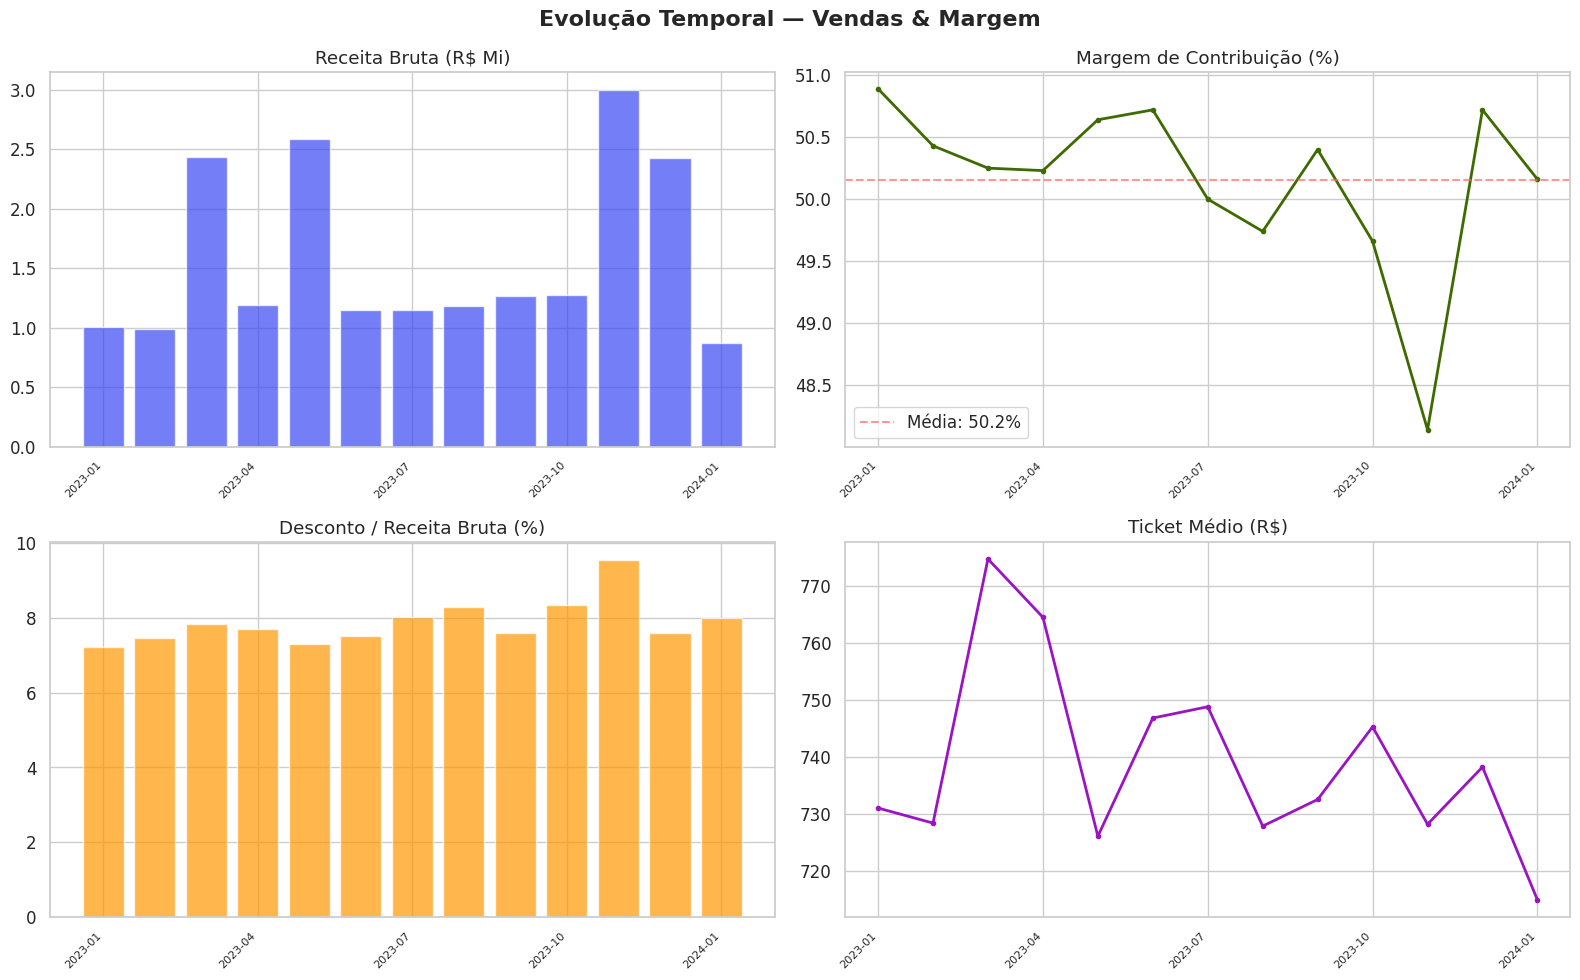


📈 Resumo da Evolução:
   Receita bruta total:       R$   20,526,133.84
   Margem contribuição total: R$   10,270,436.65
   Margem média:              50.04%
   Desconto total concedido:  R$    1,636,799.83


In [6]:
# 3.1 — Evolução temporal: Receita vs. Margem
vendas['ano_mes'] = vendas['data_pedido'].dt.to_period('M')

evolucao = vendas.groupby('ano_mes').agg(
    receita_bruta=('receita_bruta', 'sum'),
    receita_liquida=('receita_liquida', 'sum'),
    margem_total=('margem_contribuicao', 'sum'),
    desconto_total=('desconto_reais', 'sum'),
    num_pedidos=('order_id', 'nunique'),
    qtd_itens=('quantidade', 'sum')
).reset_index()

evolucao['margem_pct'] = (evolucao['margem_total'] / evolucao['receita_bruta'] * 100).round(2)
evolucao['desconto_pct'] = (evolucao['desconto_total'] / evolucao['receita_bruta'] * 100).round(2)
evolucao['ticket_medio'] = (evolucao['receita_bruta'] / evolucao['num_pedidos']).round(2)
evolucao['ano_mes_str'] = evolucao['ano_mes'].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Evolução Temporal — Vendas & Margem', fontsize=16, fontweight='bold')

# Receita
axes[0,0].bar(range(len(evolucao)), evolucao['receita_bruta']/1e6, color=COLORS['blue'], alpha=0.7)
axes[0,0].set_title('Receita Bruta (R$ Mi)')
axes[0,0].set_xticks(range(0, len(evolucao), 3))
axes[0,0].set_xticklabels(evolucao['ano_mes_str'].iloc[::3], rotation=45, ha='right', fontsize=8)

# Margem %
axes[0,1].plot(range(len(evolucao)), evolucao['margem_pct'], color=COLORS['green'], linewidth=2, marker='o', markersize=3)
axes[0,1].axhline(y=evolucao['margem_pct'].mean(), color=COLORS['red'], linestyle='--', alpha=0.7, label=f'Média: {evolucao["margem_pct"].mean():.1f}%')
axes[0,1].set_title('Margem de Contribuição (%)')
axes[0,1].legend()
axes[0,1].set_xticks(range(0, len(evolucao), 3))
axes[0,1].set_xticklabels(evolucao['ano_mes_str'].iloc[::3], rotation=45, ha='right', fontsize=8)

# Desconto %
axes[1,0].bar(range(len(evolucao)), evolucao['desconto_pct'], color=COLORS['orange'], alpha=0.7)
axes[1,0].set_title('Desconto / Receita Bruta (%)')
axes[1,0].set_xticks(range(0, len(evolucao), 3))
axes[1,0].set_xticklabels(evolucao['ano_mes_str'].iloc[::3], rotation=45, ha='right', fontsize=8)

# Ticket Médio
axes[1,1].plot(range(len(evolucao)), evolucao['ticket_medio'], color=COLORS['purple'], linewidth=2, marker='o', markersize=3)
axes[1,1].set_title('Ticket Médio (R$)')
axes[1,1].set_xticks(range(0, len(evolucao), 3))
axes[1,1].set_xticklabels(evolucao['ano_mes_str'].iloc[::3], rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

print("\n📈 Resumo da Evolução:")
print(f"   Receita bruta total:       R$ {vendas['receita_bruta'].sum():>15,.2f}")
print(f"   Margem contribuição total: R$ {vendas['margem_contribuicao'].sum():>15,.2f}")
print(f"   Margem média:              {(vendas['margem_contribuicao'].sum() / vendas['receita_bruta'].sum() * 100):.2f}%")
print(f"   Desconto total concedido:  R$ {vendas['desconto_reais'].sum():>15,.2f}")


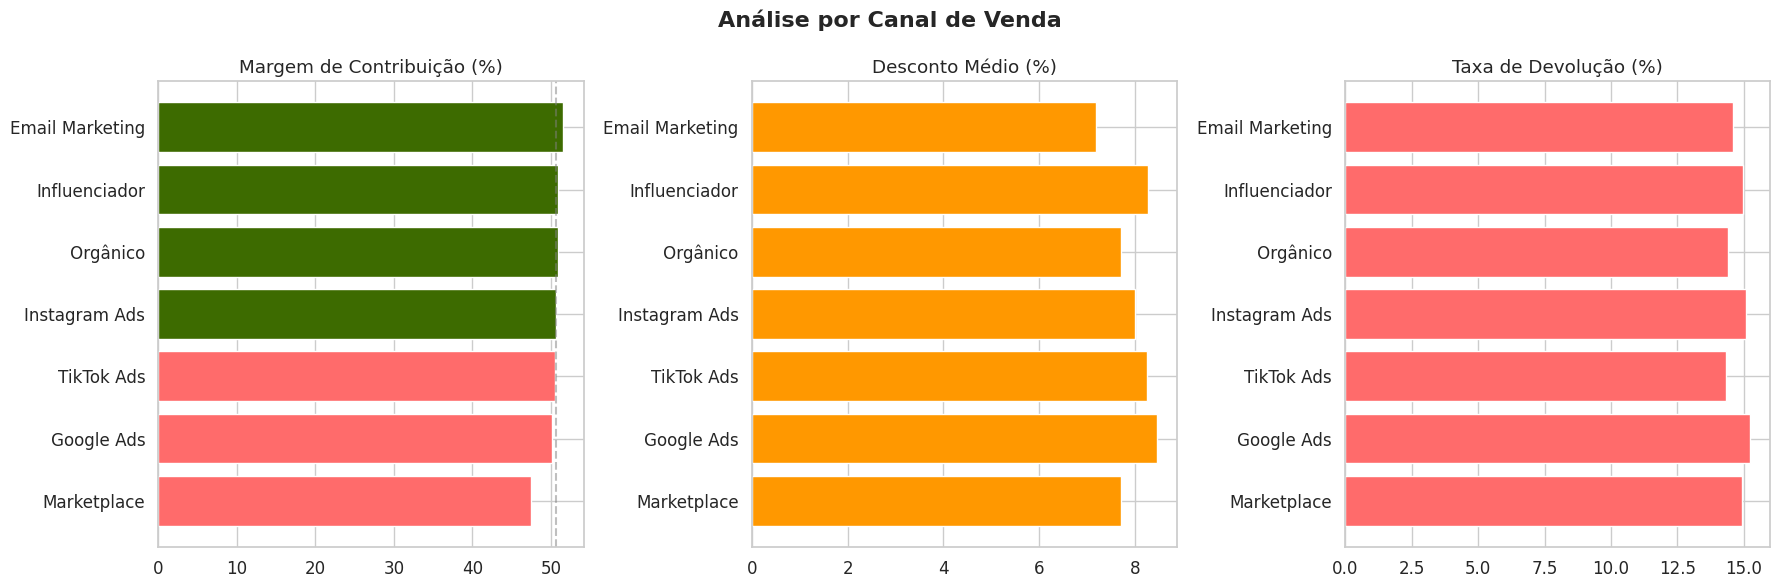

,canal,num_pedidos,receita_bruta,margem_total,margem_pct,desconto_pct,taxa_devolucao,ticket_medio
4,Marketplace,6040,4320195.69,2050034.23,47.45,7.72,14.95,715.26
1,Google Ads,5504,3979241.06,1997771.23,50.20,8.46,15.24,722.97
6,TikTok Ads,2928,2065684.06,1044491.96,50.56,8.26,14.34,705.49
3,Instagram Ads,4965,3555245.17,1800228.35,50.64,8.00,15.07,716.06
5,Orgânico,3246,2316434.49,1179151.85,50.90,7.71,14.42,713.63
2,Influenciador,2263,2250914.31,1147084.67,50.96,8.27,14.98,994.66
0,Email Marketing,2812,2038419.06,1051674.36,51.59,7.20,14.58,724.90


In [7]:
# 3.2 — Margem por CANAL de venda
margem_canal = vendas.groupby('canal').agg(
    receita_bruta=('receita_bruta', 'sum'),
    margem_total=('margem_contribuicao', 'sum'),
    desconto_total=('desconto_reais', 'sum'),
    custo_frete_total=('custo_frete', 'sum'),
    num_pedidos=('order_id', 'nunique'),
    taxa_devolucao=('devolvido', 'mean')
).reset_index()

margem_canal['margem_pct'] = (margem_canal['margem_total'] / margem_canal['receita_bruta'] * 100).round(2)
margem_canal['desconto_pct'] = (margem_canal['desconto_total'] / margem_canal['receita_bruta'] * 100).round(2)
margem_canal['ticket_medio'] = (margem_canal['receita_bruta'] / margem_canal['num_pedidos']).round(2)
margem_canal['taxa_devolucao'] = (margem_canal['taxa_devolucao'] * 100).round(2)
margem_canal = margem_canal.sort_values('margem_pct', ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Análise por Canal de Venda', fontsize=16, fontweight='bold')

colors_bar = [COLORS['red'] if x < margem_canal['margem_pct'].median() else COLORS['green'] for x in margem_canal['margem_pct']]
axes[0].barh(margem_canal['canal'], margem_canal['margem_pct'], color=colors_bar)
axes[0].set_title('Margem de Contribuição (%)')
axes[0].axvline(x=margem_canal['margem_pct'].median(), color='gray', linestyle='--', alpha=0.5)

axes[1].barh(margem_canal['canal'], margem_canal['desconto_pct'], color=COLORS['orange'])
axes[1].set_title('Desconto Médio (%)')

axes[2].barh(margem_canal['canal'], margem_canal['taxa_devolucao'], color=COLORS['red'])
axes[2].set_title('Taxa de Devolução (%)')

plt.tight_layout()
plt.show()

display(margem_canal[['canal', 'num_pedidos', 'receita_bruta', 'margem_total', 'margem_pct', 'desconto_pct', 'taxa_devolucao', 'ticket_medio']].sort_values('margem_pct'))


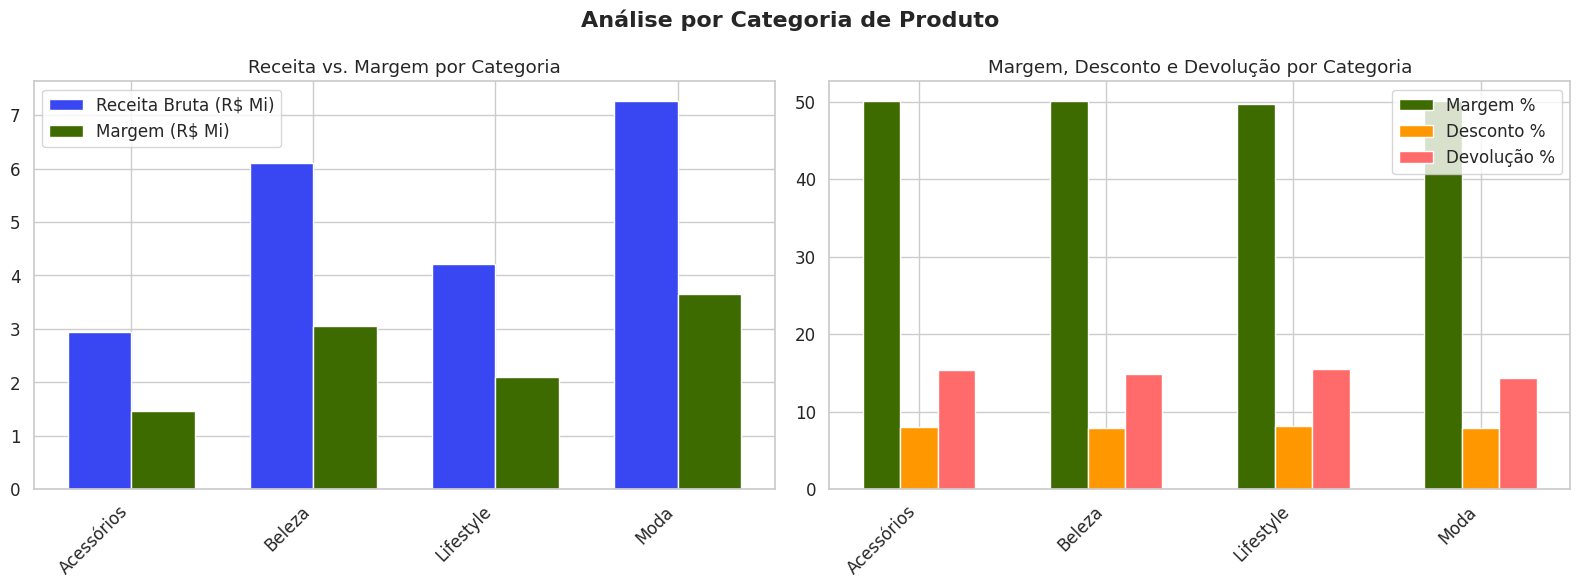

,categoria,receita_bruta,margem_total,desconto_total,custo_frete,num_pedidos,qtd_itens,taxa_devolucao,margem_pct,desconto_pct,frete_pct
2,Lifestyle,4206064.49,2091828.68,341267.21,68033.25,5629,19926.0,15.49,49.73,8.11,1.62
0,Acessórios,2939891.95,1471697.95,237181.48,50142.04,4074,14100.0,15.34,50.06,8.07,1.71
1,Beleza,6109789.41,3061752.89,480649.36,104114.95,8347,29089.0,14.87,50.11,7.87,1.70
3,Moda,7270387.99,3645157.13,577701.78,118003.53,9708,34305.0,14.31,50.14,7.95,1.62


In [8]:
# 3.3 — Margem por CATEGORIA
margem_cat = vendas.groupby('categoria').agg(
    receita_bruta=('receita_bruta', 'sum'),
    margem_total=('margem_contribuicao', 'sum'),
    desconto_total=('desconto_reais', 'sum'),
    custo_frete=('custo_frete', 'sum'),
    num_pedidos=('order_id', 'nunique'),
    qtd_itens=('quantidade', 'sum'),
    taxa_devolucao=('devolvido', 'mean')
).reset_index()

margem_cat['margem_pct'] = (margem_cat['margem_total'] / margem_cat['receita_bruta'] * 100).round(2)
margem_cat['desconto_pct'] = (margem_cat['desconto_total'] / margem_cat['receita_bruta'] * 100).round(2)
margem_cat['frete_pct'] = (margem_cat['custo_frete'] / margem_cat['receita_bruta'] * 100).round(2)
margem_cat['taxa_devolucao'] = (margem_cat['taxa_devolucao'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análise por Categoria de Produto', fontsize=16, fontweight='bold')

# Composição de receita e margem por categoria
x = np.arange(len(margem_cat))
width = 0.35
axes[0].bar(x - width/2, margem_cat['receita_bruta']/1e6, width, label='Receita Bruta (R$ Mi)', color=COLORS['blue'])
axes[0].bar(x + width/2, margem_cat['margem_total']/1e6, width, label='Margem (R$ Mi)', color=COLORS['green'])
axes[0].set_xticks(x)
axes[0].set_xticklabels(margem_cat['categoria'], rotation=45, ha='right')
axes[0].legend()
axes[0].set_title('Receita vs. Margem por Categoria')

# Margem %, Desconto % e Devolução %
axes[1].bar(x - 0.2, margem_cat['margem_pct'], 0.2, label='Margem %', color=COLORS['green'])
axes[1].bar(x, margem_cat['desconto_pct'], 0.2, label='Desconto %', color=COLORS['orange'])
axes[1].bar(x + 0.2, margem_cat['taxa_devolucao'], 0.2, label='Devolução %', color=COLORS['red'])
axes[1].set_xticks(x)
axes[1].set_xticklabels(margem_cat['categoria'], rotation=45, ha='right')
axes[1].legend()
axes[1].set_title('Margem, Desconto e Devolução por Categoria')

plt.tight_layout()
plt.show()

display(margem_cat.sort_values('margem_pct'))


⚠️ PEDIDOS COM MARGEM NEGATIVA:
   Quantidade:    491 (1.8% do total)
   Perda total:   R$ -6,636.11



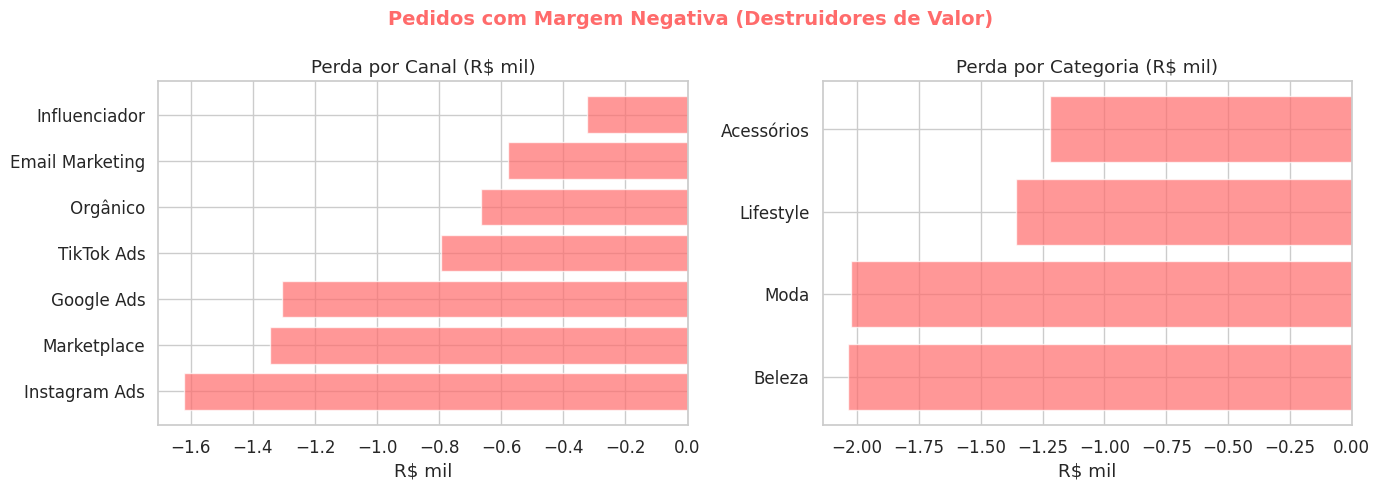

In [9]:
# 3.4 — Pedidos com margem NEGATIVA (destruidores de valor)
vendas['margem_negativa'] = vendas['margem_contribuicao'] < 0
n_neg = vendas['margem_negativa'].sum()
pct_neg = vendas['margem_negativa'].mean() * 100
perda_total = vendas.loc[vendas['margem_negativa'], 'margem_contribuicao'].sum()

print(f"⚠️ PEDIDOS COM MARGEM NEGATIVA:")
print(f"   Quantidade:    {n_neg:,} ({pct_neg:.1f}% do total)")
print(f"   Perda total:   R$ {perda_total:,.2f}")
print()

# Por canal
neg_canal = vendas[vendas['margem_negativa']].groupby('canal').agg(
    qtd_pedidos=('order_id', 'count'),
    perda_total=('margem_contribuicao', 'sum')
).sort_values('perda_total')

# Por categoria
neg_cat = vendas[vendas['margem_negativa']].groupby('categoria').agg(
    qtd_pedidos=('order_id', 'count'),
    perda_total=('margem_contribuicao', 'sum')
).sort_values('perda_total')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pedidos com Margem Negativa (Destruidores de Valor)', fontsize=14, fontweight='bold', color=COLORS['red'])

axes[0].barh(neg_canal.index, neg_canal['perda_total']/1e3, color=COLORS['red'], alpha=0.7)
axes[0].set_title('Perda por Canal (R$ mil)')
axes[0].set_xlabel('R$ mil')

axes[1].barh(neg_cat.index, neg_cat['perda_total']/1e3, color=COLORS['red'], alpha=0.7)
axes[1].set_title('Perda por Categoria (R$ mil)')
axes[1].set_xlabel('R$ mil')

plt.tight_layout()
plt.show()


📦 DEVOLUÇÕES:
   Total de devoluções:                  4,127
   Taxa geral de devolução:              14.87%
   Receita bruta associada aos pedidos: R$ 3,063,301.17
   Observação: esse valor não representa perda líquida ou margem recuperável.
   Faltam reembolso, recuperação do produto, logística reversa e processamento.

🔍 Motivos de Devolução:
   Produto com defeito                 → 1,039 (25.2%)
   Tamanho errado                      → 1,025 (24.8%)
   Atraso na entrega                   → 808 (19.6%)
   Não gostei                          → 669 (16.2%)
   Arrependimento                      → 586 (14.2%)


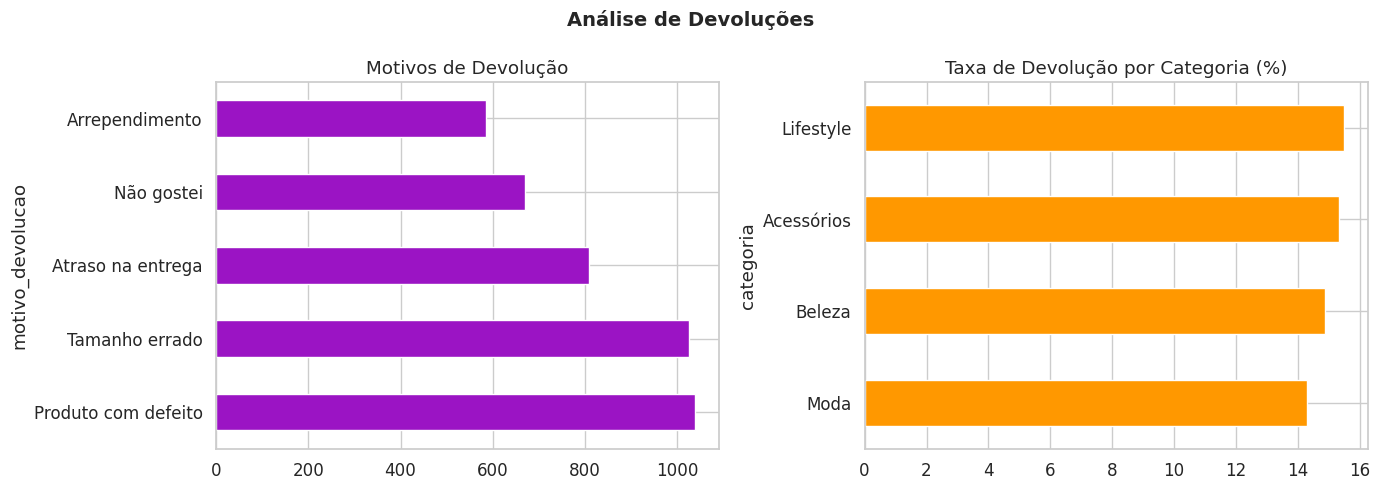

In [10]:
# 3.5 — Análise de Devoluções
devolucoes = vendas[vendas['devolvido'] == 1].copy()

print('📦 DEVOLUÇÕES:')
print(f'   Total de devoluções:                  {len(devolucoes):,}')
print(f'   Taxa geral de devolução:              {len(devolucoes)/len(vendas)*100:.2f}%')
print(f"   Receita bruta associada aos pedidos: R$ {devolucoes['receita_bruta'].sum():,.2f}")
print('   Observação: esse valor não representa perda líquida ou margem recuperável.')
print('   Faltam reembolso, recuperação do produto, logística reversa e processamento.\n')

motivos = devolucoes['motivo_devolucao'].value_counts()
print('🔍 Motivos de Devolução:')
for motivo, qtd in motivos.items():
    print(f'   {motivo:35s} → {qtd:,} ({qtd/len(devolucoes)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análise de Devoluções', fontsize=14, fontweight='bold')
motivos.plot(kind='barh', ax=axes[0], color=COLORS['purple'])
axes[0].set_title('Motivos de Devolução')

dev_cat = vendas.groupby('categoria')['devolvido'].mean() * 100
dev_cat.sort_values().plot(kind='barh', ax=axes[1], color=COLORS['orange'])
axes[1].set_title('Taxa de Devolução por Categoria (%)')
plt.tight_layout()
plt.show()

---
## 4. 📣 Análise de Marketing & Canais

> **Hipótese do case:** *"Nem todo crescimento de aquisição gera clientes igualmente valiosos"*
> 
> **Objetivo:** Classificar canais por qualidade de aquisição e recomendar realocação de investimento de marketing com base em rentabilidade de longo prazo.


In [11]:
# 4.1 — Visão geral de investimento por canal
mkt_canal = marketing.groupby('canal').agg(
    investimento=('investimento_reais', 'sum'),
    impressoes=('impressoes', 'sum'),
    cliques=('cliques', 'sum'),
    conversoes=('conversoes', 'sum'),
    receita=('receita_gerada', 'sum'),
    campanhas=('campanha_id', 'nunique'),
    cac_medio=('cac', 'mean'),
    roas_medio=('roas', 'mean')
).reset_index()

mkt_canal['ctr'] = (mkt_canal['cliques'] / mkt_canal['impressoes'] * 100).round(2)
mkt_canal['cvr'] = (mkt_canal['conversoes'] / mkt_canal['cliques'] * 100).round(2)
mkt_canal['roas_real'] = (mkt_canal['receita'] / mkt_canal['investimento']).round(2)
mkt_canal['custo_por_conversao'] = (mkt_canal['investimento'] / mkt_canal['conversoes']).round(2)

display(mkt_canal.sort_values('roas_real', ascending=False))


,canal,investimento,impressoes,cliques,conversoes,receita,campanhas,cac_medio,roas_medio,ctr,cvr,roas_real,custo_por_conversao
2,Influenciador,28061599.02,6734376424,241081421,15940484,2.175780e+08,465,4.173484,7.691548,3.58,6.61,7.75,1.76
6,TikTok Ads,29770101.07,7258701523,258038032,17009948,1.390634e+08,488,3.954672,4.667111,3.55,6.59,4.67,1.75
3,Instagram Ads,30165772.33,7036628198,233280842,15360484,1.359386e+08,518,4.716699,4.426390,3.32,6.58,4.51,1.96
1,Google Ads,30224839.25,7276888260,250841055,16118323,1.065574e+08,509,4.269627,3.513536,3.45,6.43,3.53,1.88
0,Email Marketing,29700531.98,7190708958,248127946,16563197,9.104621e+07,485,4.291546,2.997897,3.45,6.68,3.07,1.79
4,Marketplace,32682629.69,8028787619,271482915,17894187,9.879591e+07,540,4.385963,3.004519,3.38,6.59,3.02,1.83
5,Orgânico,29808867.75,7090741183,234763601,16401820,8.964926e+07,495,4.655960,2.993434,3.31,6.99,3.01,1.82


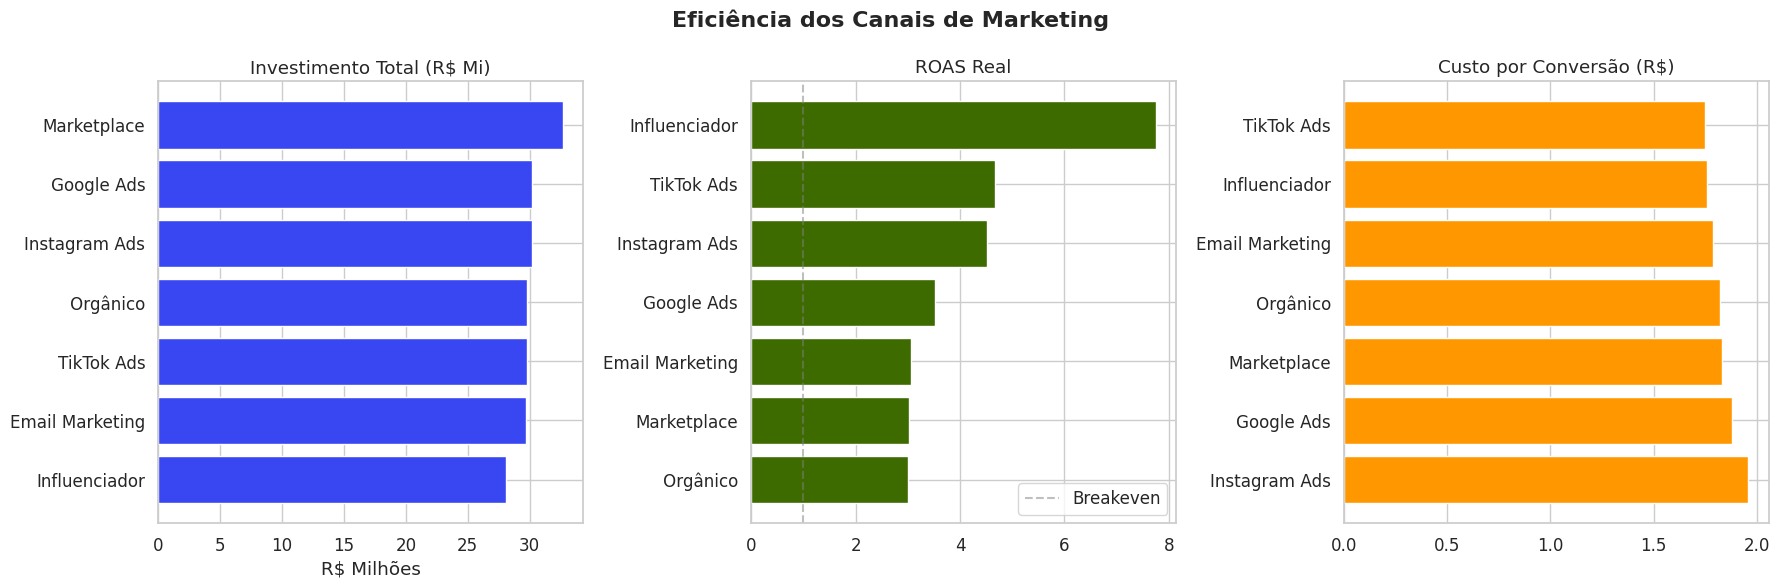


📊 Insight: Canais com melhor ROAS e menor CAC devem receber mais investimento.
   Canais com ROAS < 1 estão destruindo valor por real investido.


In [12]:
# 4.2 — ROAS vs. Investimento vs. CAC
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Eficiência dos Canais de Marketing', fontsize=16, fontweight='bold')

# Investimento
mkt_sorted = mkt_canal.sort_values('investimento', ascending=True)
axes[0].barh(mkt_sorted['canal'], mkt_sorted['investimento']/1e6, color=COLORS['blue'])
axes[0].set_title('Investimento Total (R$ Mi)')
axes[0].set_xlabel('R$ Milhões')

# ROAS
mkt_sorted_roas = mkt_canal.sort_values('roas_real', ascending=True)
colors_roas = [COLORS['red'] if x < 1 else COLORS['green'] for x in mkt_sorted_roas['roas_real']]
axes[1].barh(mkt_sorted_roas['canal'], mkt_sorted_roas['roas_real'], color=colors_roas)
axes[1].axvline(x=1, color='gray', linestyle='--', alpha=0.5, label='Breakeven')
axes[1].set_title('ROAS Real')
axes[1].legend()

# CAC
mkt_sorted_cac = mkt_canal.sort_values('custo_por_conversao', ascending=False)
axes[2].barh(mkt_sorted_cac['canal'], mkt_sorted_cac['custo_por_conversao'], color=COLORS['orange'])
axes[2].set_title('Custo por Conversão (R$)')

plt.tight_layout()
plt.show()

print("\n📊 Insight: Canais com melhor ROAS e menor CAC devem receber mais investimento.")
print("   Canais com ROAS < 1 estão destruindo valor por real investido.")


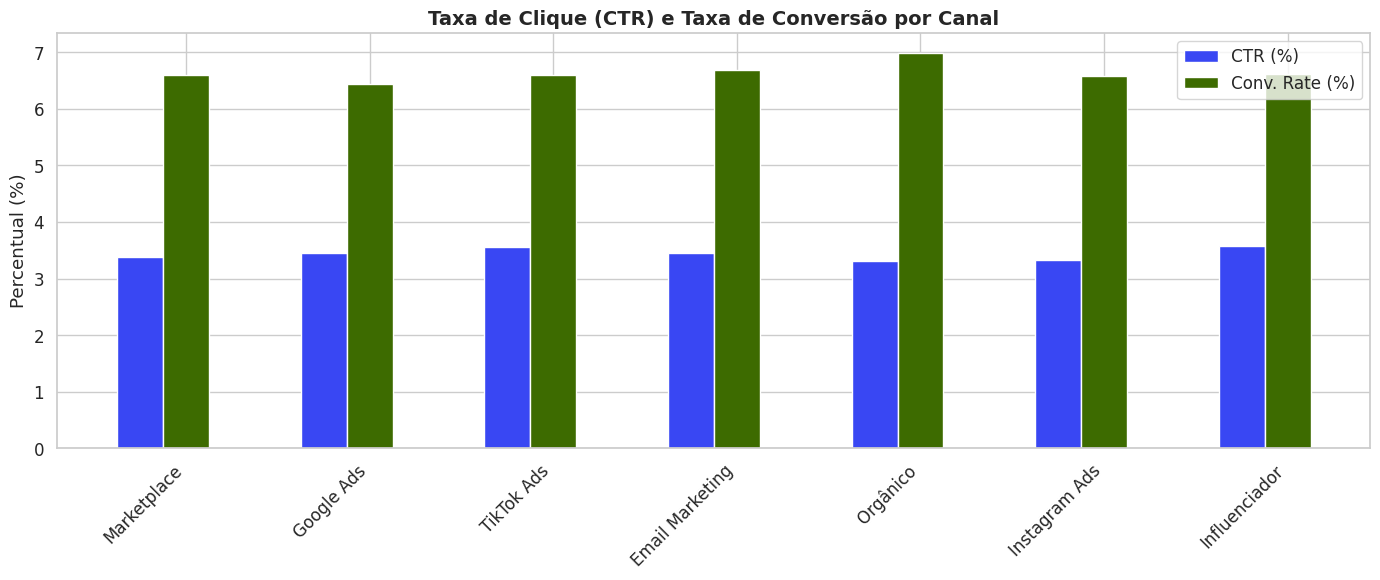

In [13]:
# 4.3 — Funil de Conversão por Canal
fig, ax = plt.subplots(figsize=(14, 6))

canais = mkt_canal.sort_values('impressoes', ascending=False)['canal']
x = np.arange(len(canais))
width = 0.25

ax.bar(x - width, mkt_canal.set_index('canal').loc[canais, 'ctr'], width, label='CTR (%)', color=COLORS['blue'])
ax.bar(x, mkt_canal.set_index('canal').loc[canais, 'cvr'], width, label='Conv. Rate (%)', color=COLORS['green'])
ax.set_xticks(x)
ax.set_xticklabels(canais, rotation=45, ha='right')
ax.legend()
ax.set_title('Taxa de Clique (CTR) e Taxa de Conversão por Canal', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentual (%)')

plt.tight_layout()
plt.show()


In [14]:
# 4.4 — Análise de Campanhas: Melhores e piores
print("🏆 TOP 10 Campanhas por ROAS:")
display(marketing.nlargest(10, 'roas')[['campanha_id', 'nome_campanha', 'canal', 'investimento_reais', 'receita_gerada', 'roas', 'cac', 'conversoes']])

print("\n⚠️ BOTTOM 10 Campanhas por ROAS (piores):")
display(marketing.nsmallest(10, 'roas')[['campanha_id', 'nome_campanha', 'canal', 'investimento_reais', 'receita_gerada', 'roas', 'cac', 'conversoes']])


🏆 TOP 10 Campanhas por ROAS:


,campanha_id,nome_campanha,canal,investimento_reais,receita_gerada,roas,cac,conversoes
833,CAMP-0834,Stories_Boost_2025_04,Influenciador,62421.70,932580.20,14.94,1.72,36277
2747,CAMP-2748,Natal_Presentes_2025_08,Influenciador,48410.93,722775.18,14.93,5.90,8208
224,CAMP-0225,Performance_Moda_2024_09,Influenciador,33717.16,502722.86,14.91,4.09,8237
1919,CAMP-1920,TikTok_Viral_2023,Influenciador,99882.16,1486246.54,14.88,0.47,213968
2848,CAMP-2849,Remarketing_30d_2023_12,Influenciador,34921.75,518587.99,14.85,3.54,9873
1753,CAMP-1754,Volta_as_Aulas_2025_11,Influenciador,99679.22,1469271.70,14.74,4.98,20014
2526,CAMP-2527,Performance_Sempre_Ligada_2023,Influenciador,7303.44,107433.60,14.71,2.73,2679
1820,CAMP-1821,Remarketing_30d_2023_12,Influenciador,1607.74,23633.78,14.70,2.05,785
3058,CAMP-3059,Volta_as_Aulas_2023_09,Influenciador,68168.66,1001397.62,14.69,2.76,24655
691,CAMP-0692,Upsell_Platinum_2024,Influenciador,111959.24,1643561.64,14.68,3.56,31458



⚠️ BOTTOM 10 Campanhas por ROAS (piores):


,campanha_id,nome_campanha,canal,investimento_reais,receita_gerada,roas,cac,conversoes
570,CAMP-0571,Lancamento_Colecao_2023_09,Influenciador,119035.77,63088.96,0.53,2.45,48517
539,CAMP-0540,Feed_Carousel_2025,Influenciador,40285.98,24171.59,0.60,2.65,15192
290,CAMP-0291,Performance_Moda_2023_11,Influenciador,114046.93,71849.57,0.63,1.53,74326
2070,CAMP-2071,Semana_Consumidor_2025,Influenciador,69825.65,44688.42,0.64,32.91,2122
794,CAMP-0795,Parceria_Creator_2023_09,Influenciador,73942.56,50280.94,0.68,1.26,58787
1729,CAMP-1730,Dia_Das_Maes_2024,Influenciador,88938.70,61367.70,0.69,1.18,75205
871,CAMP-0872,Cyber_Monday_2024,Influenciador,33117.29,25169.14,0.76,1.12,29591
2598,CAMP-2599,Lancamento_Colecao_2025_10,Influenciador,61955.87,52662.49,0.85,0.64,96734
783,CAMP-0784,Branding_Awareness_2023,Influenciador,51895.56,45668.09,0.88,0.93,56053
2315,CAMP-2316,UGC_Organico_2023_12,Influenciador,89355.20,83100.34,0.93,1.15,77558


---
## 5. 👤 Análise de Clientes & Segmentação

> **Hipótese do case:** *"O crescimento pode esconder diferenças importantes entre segmentos de clientes"*
> 
> **Objetivo:** Segmentar a base de clientes e identificar quais segmentos devem receber ações de retenção, upsell ou redução de investimento.


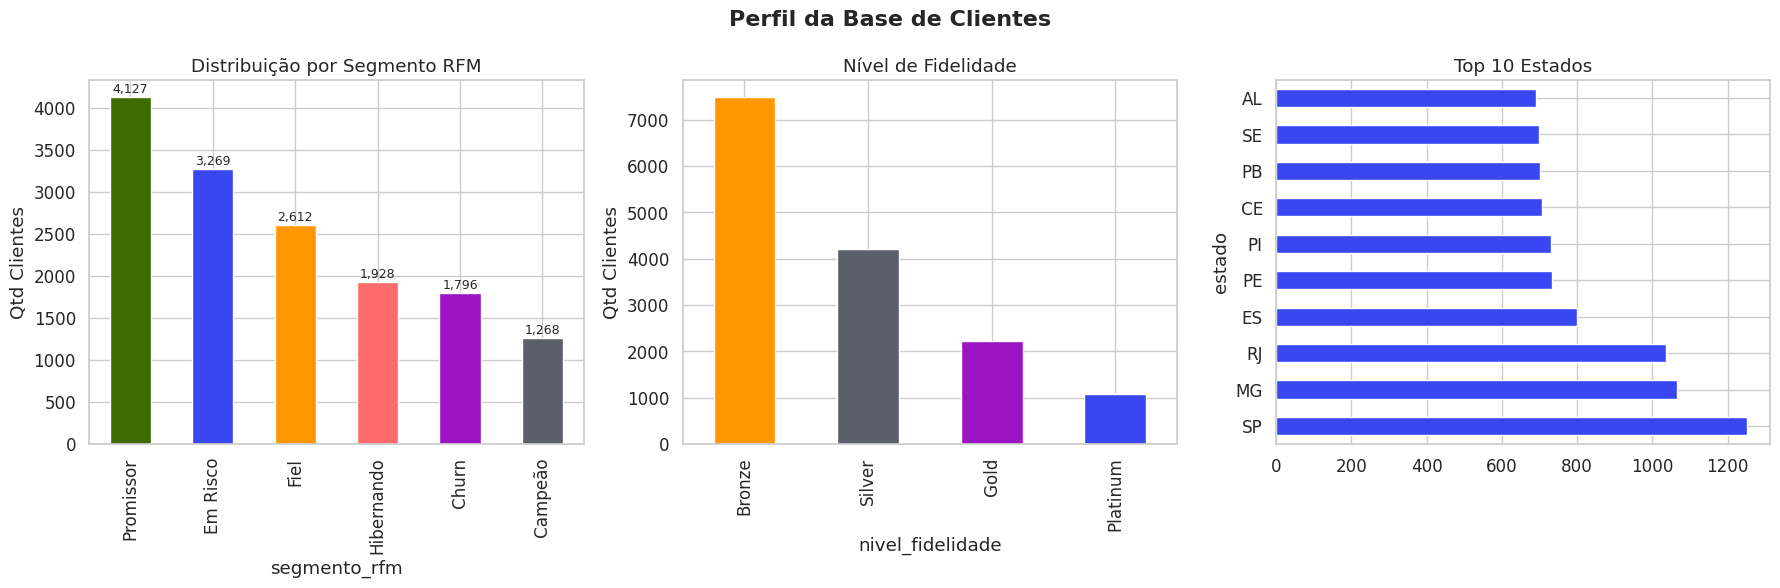

In [15]:
# 5.1 — Distribuição por Segmento RFM
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Perfil da Base de Clientes', fontsize=16, fontweight='bold')

# Segmentos
seg_counts = clientes['segmento_rfm'].value_counts()
colors_seg = [COLORS['green'], COLORS['blue'], COLORS['orange'], COLORS['red'], COLORS['purple'], COLORS['gray']]
seg_counts.plot(kind='bar', ax=axes[0], color=colors_seg[:len(seg_counts)])
axes[0].set_title('Distribuição por Segmento RFM')
axes[0].set_ylabel('Qtd Clientes')
for i, v in enumerate(seg_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

# Nível de Fidelidade
fid_counts = clientes['nivel_fidelidade'].value_counts()
fid_counts.plot(kind='bar', ax=axes[1], color=[COLORS['orange'], COLORS['gray'], COLORS['purple'], COLORS['blue']])
axes[1].set_title('Nível de Fidelidade')
axes[1].set_ylabel('Qtd Clientes')

# Região
reg_counts = clientes['estado'].value_counts().head(10)
reg_counts.plot(kind='barh', ax=axes[2], color=COLORS['blue'])
axes[2].set_title('Top 10 Estados')

plt.tight_layout()
plt.show()


,segmento_rfm,qtd_clientes,ltv_medio,ltv_total,pedidos_medio,renda_media,pct_clientes,pct_ltv
0,Campeão,1268,26670.755781,33818518.33,54.010252,13804.972957,8.5,24.3
3,Fiel,2612,16896.754556,44134322.90,34.248086,13972.821853,17.4,31.7
5,Promissor,4127,8077.970167,33337782.88,15.979404,13779.187155,27.5,24.0
2,Em Risco,3269,5403.483197,17663986.57,10.696849,13713.558633,21.8,12.7
1,Churn,1796,2782.084538,4996623.83,5.417595,13807.756008,12.0,3.6
4,Hibernando,1928,2666.667184,5141334.33,5.332988,13617.173226,12.9,3.7


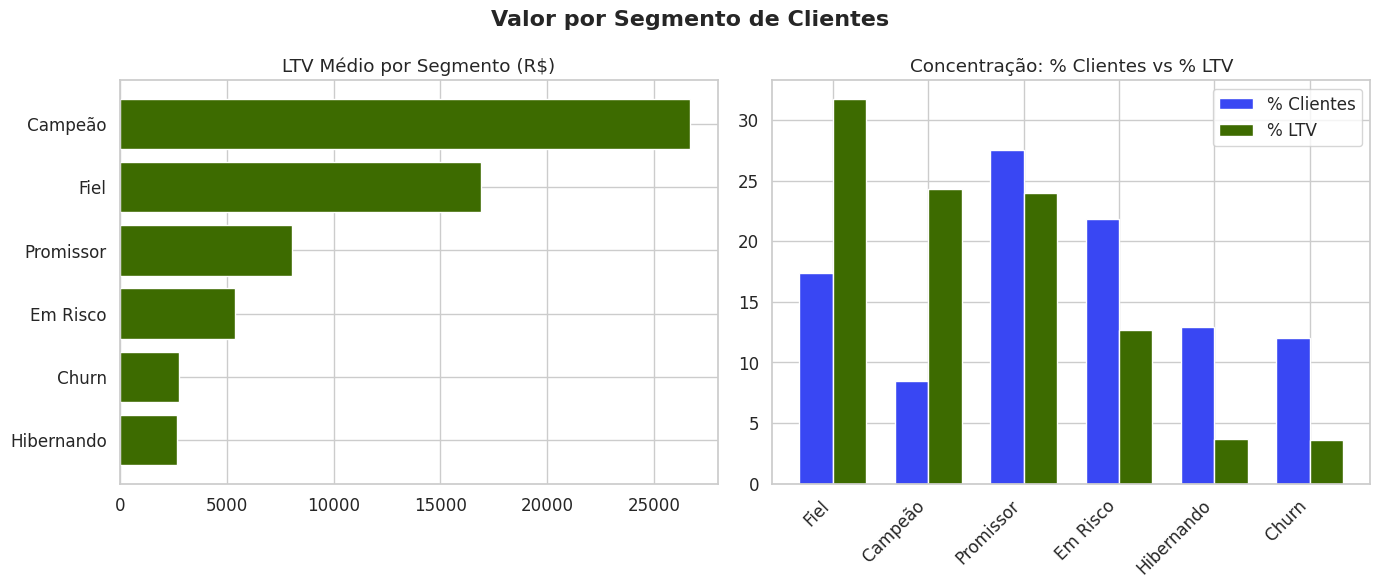


💡 Insight: Buscar segmentos onde poucos clientes concentram muito LTV (alto valor)
   e segmentos onde muitos clientes geram pouco LTV (oportunidade de retenção/upsell).


In [16]:
# 5.2 — LTV e Valor por Segmento
seg_valor = clientes.groupby('segmento_rfm').agg(
    qtd_clientes=('customer_id', 'count'),
    ltv_medio=('ltv_acumulado', 'mean'),
    ltv_total=('ltv_acumulado', 'sum'),
    pedidos_medio=('total_pedidos_historico', 'mean'),
    renda_media=('renda_estimada', 'mean')
).reset_index()

seg_valor['pct_clientes'] = (seg_valor['qtd_clientes'] / seg_valor['qtd_clientes'].sum() * 100).round(1)
seg_valor['pct_ltv'] = (seg_valor['ltv_total'] / seg_valor['ltv_total'].sum() * 100).round(1)

display(seg_valor.sort_values('ltv_medio', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Valor por Segmento de Clientes', fontsize=16, fontweight='bold')

# LTV médio
seg_sorted = seg_valor.sort_values('ltv_medio')
axes[0].barh(seg_sorted['segmento_rfm'], seg_sorted['ltv_medio'], color=COLORS['green'])
axes[0].set_title('LTV Médio por Segmento (R$)')

# % Clientes vs % LTV
x = np.arange(len(seg_valor))
width = 0.35
seg_v = seg_valor.sort_values('pct_ltv', ascending=False)
axes[1].bar(x - width/2, seg_v['pct_clientes'], width, label='% Clientes', color=COLORS['blue'])
axes[1].bar(x + width/2, seg_v['pct_ltv'], width, label='% LTV', color=COLORS['green'])
axes[1].set_xticks(x)
axes[1].set_xticklabels(seg_v['segmento_rfm'], rotation=45, ha='right')
axes[1].legend()
axes[1].set_title('Concentração: % Clientes vs % LTV')

plt.tight_layout()
plt.show()

print("\n💡 Insight: Buscar segmentos onde poucos clientes concentram muito LTV (alto valor)")
print("   e segmentos onde muitos clientes geram pouco LTV (oportunidade de retenção/upsell).")


In [17]:
# 5.3 — Análise por Canal de Aquisição (se disponível) ou Nível de Fidelidade
if 'canal_aquisicao' in clientes.columns:
    col_analise = 'canal_aquisicao'
else:
    col_analise = 'nivel_fidelidade'

cli_canal = clientes.groupby(col_analise).agg(
    qtd=('customer_id', 'count'),
    ltv_medio=('ltv_acumulado', 'mean'),
    pedidos_medio=('total_pedidos_historico', 'mean'),
    renda_media=('renda_estimada', 'mean')
).reset_index()

display(cli_canal.sort_values('ltv_medio', ascending=False))


,nivel_fidelidade,qtd,ltv_medio,pedidos_medio,renda_media
2,Platinum,1083,37046.700646,74.996307,13730.590046
1,Gold,2229,18615.536976,37.336025,13978.544527
3,Silver,4203,8776.805337,17.522008,13777.417323
0,Bronze,7485,2750.574120,5.448230,13736.245149


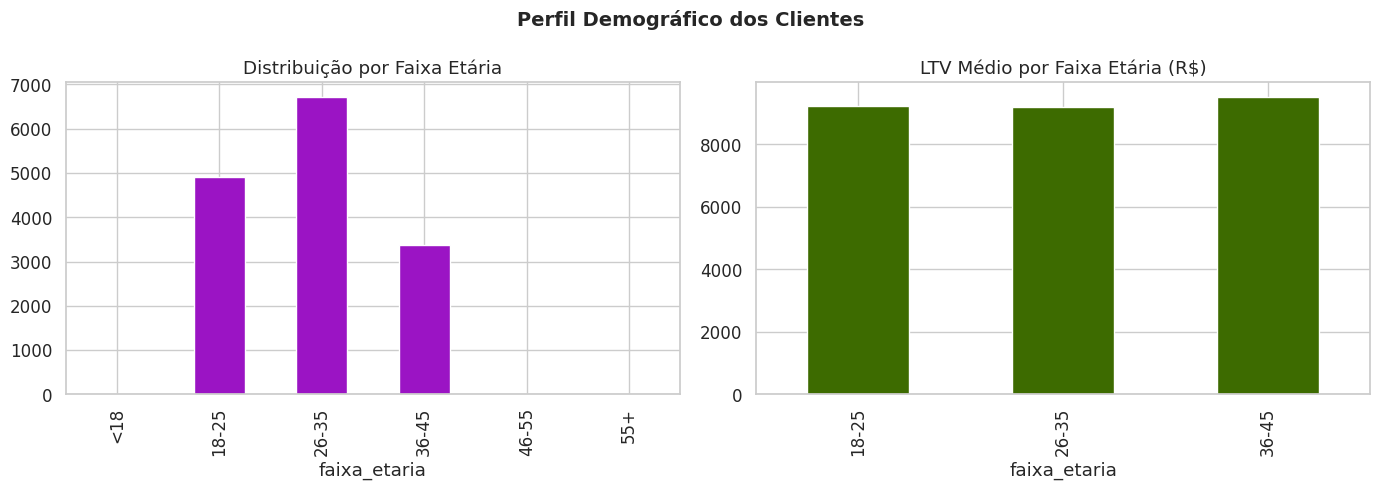

In [18]:
# 5.4 — Distribuição de idade e análise demográfica
clientes['idade'] = ((pd.Timestamp('2026-01-01') - clientes['data_nascimento']).dt.days / 365.25).astype(int)
clientes['faixa_etaria'] = pd.cut(clientes['idade'], bins=[0, 18, 25, 35, 45, 55, 100], 
                                   labels=['<18', '18-25', '26-35', '36-45', '46-55', '55+'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Perfil Demográfico dos Clientes', fontsize=14, fontweight='bold')

clientes['faixa_etaria'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=COLORS['purple'])
axes[0].set_title('Distribuição por Faixa Etária')

# LTV por faixa etária
ltv_faixa = clientes.groupby('faixa_etaria')['ltv_acumulado'].mean().sort_index()
ltv_faixa.plot(kind='bar', ax=axes[1], color=COLORS['green'])
axes[1].set_title('LTV Médio por Faixa Etária (R$)')

plt.tight_layout()
plt.show()


---
## 6. 🎧 Análise de Atendimento

> **Hipótese do case:** *"O atendimento pode estar concentrando sintomas de problemas recorrentes"*
> 
> **Objetivo:** Mapear as causas-raiz dos tickets mais frequentes e estimar o ganho de produtividade/redução de custo com automação da triagem.


In [19]:
# 6.1 — Volume e distribuição de tickets
print(f"📞 VISÃO GERAL DO ATENDIMENTO:")
print(f"   Total de tickets:              {len(atendimento):,}")
print(f"   Custo operacional total:       R$ {atendimento['custo_operacional_ticket'].sum():,.2f}")
print(f"   Custo médio por ticket:        R$ {atendimento['custo_operacional_ticket'].mean():.2f}")
print(f"   Tempo médio 1ª resposta:       {atendimento['tempo_primeira_resposta_minutos'].mean():.0f} minutos")
print(f"   CSAT médio:                    {atendimento['nota_csat'].mean():.2f}")
print()

# Status
print("📋 Status dos tickets:")
for status, qtd in atendimento['status_atendimento'].value_counts().items():
    print(f"   {status:20s} → {qtd:,} ({qtd/len(atendimento)*100:.1f}%)")


📞 VISÃO GERAL DO ATENDIMENTO:
   Total de tickets:              35,840
   Custo operacional total:       R$ 532,260.00
   Custo médio por ticket:        R$ 14.85
   Tempo médio 1ª resposta:       135 minutos
   CSAT médio:                    3.24

📋 Status dos tickets:
   Resolvido            → 23,352 (65.2%)
   Em Análise           → 5,304 (14.8%)
   Aberto               → 3,594 (10.0%)
   Escalado para N2     → 3,590 (10.0%)


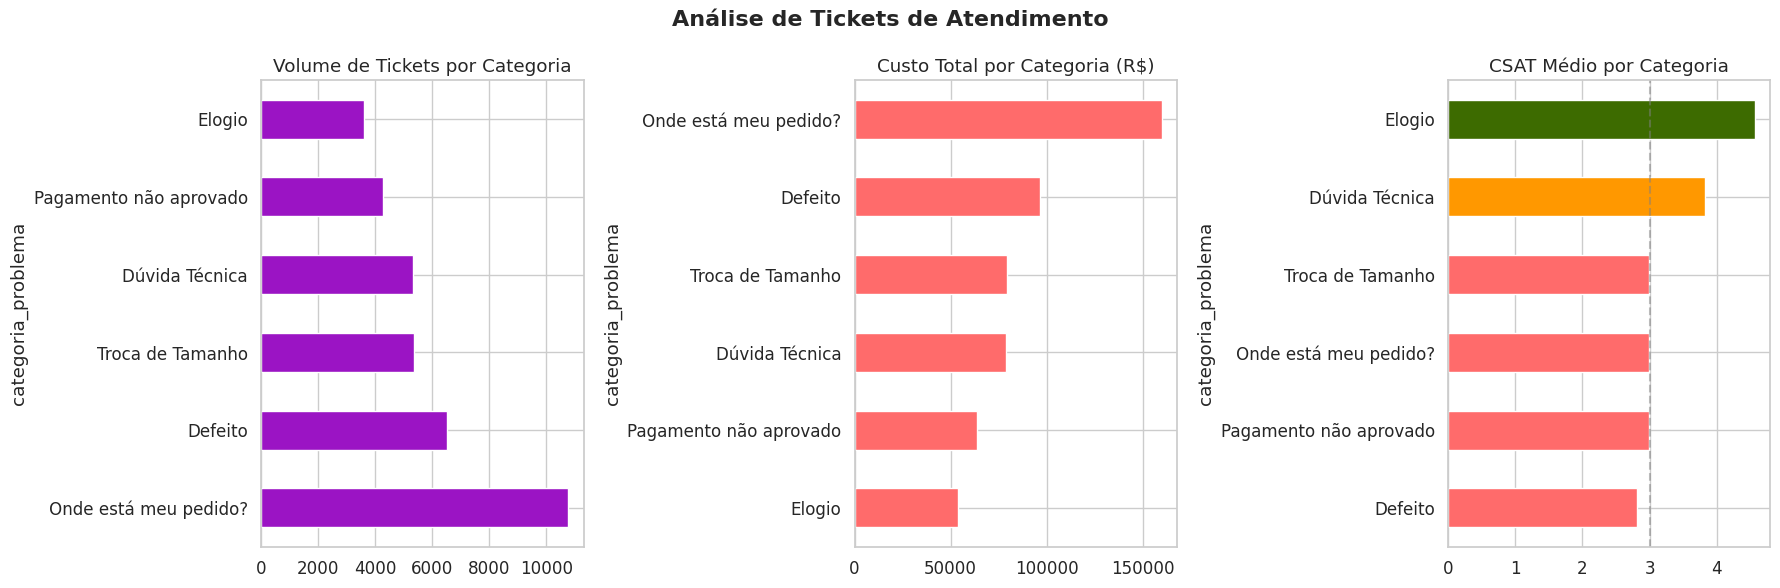

In [20]:
# 6.2 — Categorias de problema mais frequentes
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Análise de Tickets de Atendimento', fontsize=16, fontweight='bold')

# Volume por categoria
cat_tickets = atendimento['categoria_problema'].value_counts()
cat_tickets.plot(kind='barh', ax=axes[0], color=COLORS['purple'])
axes[0].set_title('Volume de Tickets por Categoria')

# Custo por categoria  
custo_cat = atendimento.groupby('categoria_problema')['custo_operacional_ticket'].sum().sort_values()
custo_cat.plot(kind='barh', ax=axes[1], color=COLORS['red'])
axes[1].set_title('Custo Total por Categoria (R$)')

# CSAT por categoria
csat_cat = atendimento.groupby('categoria_problema')['nota_csat'].mean().sort_values()
colors_csat = [COLORS['red'] if x < 3 else COLORS['orange'] if x < 4 else COLORS['green'] for x in csat_cat]
csat_cat.plot(kind='barh', ax=axes[2], color=colors_csat)
axes[2].axvline(x=3, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title('CSAT Médio por Categoria')

plt.tight_layout()
plt.show()


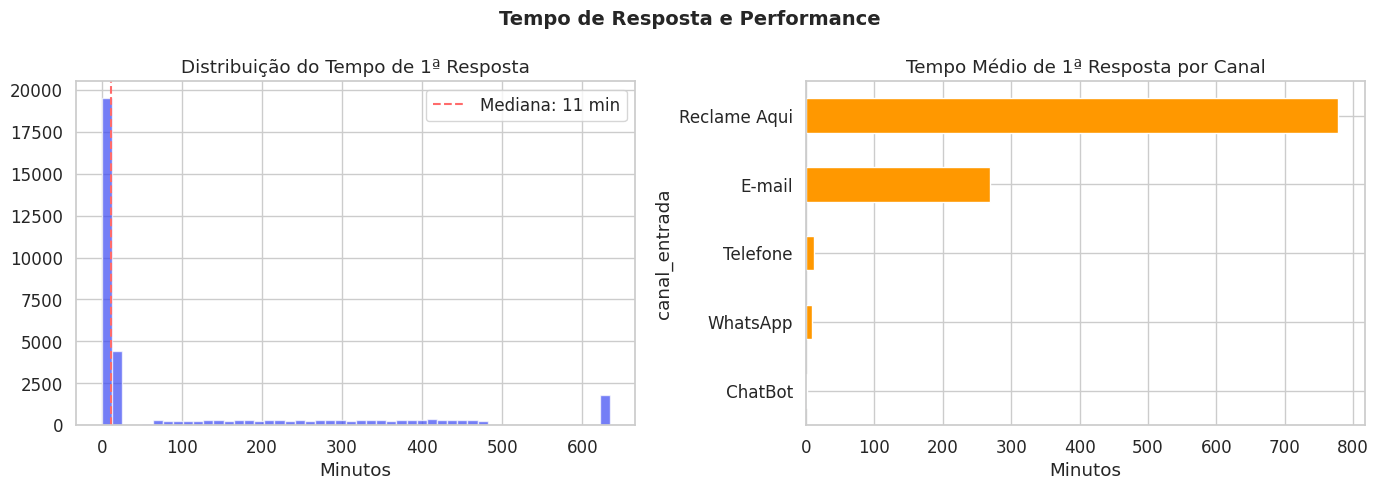

In [21]:
# 6.3 — Análise de tempo de resposta e SLA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tempo de Resposta e Performance', fontsize=14, fontweight='bold')

# Distribuição do tempo de resposta
atendimento['tempo_primeira_resposta_minutos'].clip(upper=atendimento['tempo_primeira_resposta_minutos'].quantile(0.95)).hist(
    bins=50, ax=axes[0], color=COLORS['blue'], alpha=0.7, edgecolor='white'
)
axes[0].axvline(x=atendimento['tempo_primeira_resposta_minutos'].median(), color=COLORS['red'], linestyle='--', 
                label=f'Mediana: {atendimento["tempo_primeira_resposta_minutos"].median():.0f} min')
axes[0].set_title('Distribuição do Tempo de 1ª Resposta')
axes[0].set_xlabel('Minutos')
axes[0].legend()

# Tempo médio por canal de entrada
tempo_canal = atendimento.groupby('canal_entrada')['tempo_primeira_resposta_minutos'].mean().sort_values()
tempo_canal.plot(kind='barh', ax=axes[1], color=COLORS['orange'])
axes[1].set_title('Tempo Médio de 1ª Resposta por Canal')
axes[1].set_xlabel('Minutos')

plt.tight_layout()
plt.show()


In [22]:
# 6.4 — Potencial de automação: tickets repetitivos
print('🤖 POTENCIAL DE AUTOMAÇÃO:')

cat_analise = atendimento.groupby('categoria_problema').agg(
    volume=('ticket_id', 'count'),
    custo_total=('custo_operacional_ticket', 'sum'),
    custo_medio=('custo_operacional_ticket', 'mean'),
    tempo_medio=('tempo_primeira_resposta_minutos', 'mean'),
    csat_medio=('nota_csat', 'mean'),
    pct_resolvido=('status_atendimento', lambda x: (x == 'Resolvido').mean() * 100)
).reset_index()
cat_analise['pct_volume'] = (cat_analise['volume'] / cat_analise['volume'].sum() * 100).round(1)
cat_analise = cat_analise.sort_values('volume', ascending=False)
display(cat_analise)

# Cenários, não economia validada: somente 70% do custo é assumido como variável/evitável.
top_3_custo = cat_analise.nlargest(3, 'custo_total')['custo_total'].sum()
cenarios_automacao = pd.DataFrame([
    {
        'taxa_contenção_pct': taxa * 100,
        'parcela_custo_evitável_pct': 70,
        'economia_teórica': top_3_custo * taxa * 0.70
    }
    for taxa in [0.20, 0.40, 0.60]
])
print(f'\n💰 Custo atual dos 3 maiores problemas: R$ {top_3_custo:,.2f}')
display(cenarios_automacao.round(2))
print('⚠️ Os valores são cenários. A economia real depende de contenção, custo variável e custo da solução.')

🤖 POTENCIAL DE AUTOMAÇÃO:


,categoria_problema,volume,custo_total,custo_medio,tempo_medio,csat_medio,pct_resolvido,pct_volume
3,Onde está meu pedido?,10765,159660.0,14.831398,137.004180,2.986995,65.248490,30.0
0,Defeito,6509,96592.0,14.839760,135.866800,2.817330,64.065141,18.2
5,Troca de Tamanho,5360,79325.0,14.799440,131.222201,2.991978,66.194030,15.0
1,Dúvida Técnica,5314,78888.0,14.845314,136.503952,3.827061,65.318028,14.8
4,Pagamento não aprovado,4281,63856.0,14.916141,134.332633,2.985751,65.171689,11.9
2,Elogio,3611,53939.0,14.937413,135.733038,4.569094,65.051232,10.1



💰 Custo atual dos 3 maiores problemas: R$ 335,577.00


,taxa_contenção_pct,parcela_custo_evitável_pct,economia_teórica
0,20.0,70,46980.78
1,40.0,70,93961.56
2,60.0,70,140942.34


⚠️ Os valores são cenários. A economia real depende de contenção, custo variável e custo da solução.


In [23]:
# 6.5 — Análise de satisfação (CSAT)
print("😊 ANÁLISE DE SATISFAÇÃO (CSAT):")
print()

csat_dist = atendimento['nota_csat'].value_counts().sort_index()
print("Distribuição CSAT:")
for nota, qtd in csat_dist.items():
    barra = '█' * int(qtd / csat_dist.max() * 40)
    print(f"   Nota {nota:.0f}: {barra} {qtd:,} ({qtd/len(atendimento)*100:.1f}%)")

# Tickets com CSAT baixo (1 ou 2)
baixo_csat = atendimento[atendimento['nota_csat'] <= 2]
print(f"\n⚠️ Tickets com CSAT ≤ 2: {len(baixo_csat):,} ({len(baixo_csat)/len(atendimento)*100:.1f}%)")
print(f"   Principais categorias:")
for cat, qtd in baixo_csat['categoria_problema'].value_counts().head(5).items():
    print(f"     {cat:30s} → {qtd:,}")


😊 ANÁLISE DE SATISFAÇÃO (CSAT):

Distribuição CSAT:
   Nota 1: ███████ 2,627 (7.3%)
   Nota 2: ██████████████ 5,078 (14.2%)
   Nota 3: ████████████████████████████████████████ 14,497 (40.4%)
   Nota 4: ██████████████████████ 8,316 (23.2%)
   Nota 5: ██████████████ 5,322 (14.8%)

⚠️ Tickets com CSAT ≤ 2: 7,705 (21.5%)
   Principais categorias:
     Onde está meu pedido?          → 2,720
     Defeito                        → 2,049
     Troca de Tamanho               → 1,346
     Pagamento não aprovado         → 1,091
     Dúvida Técnica                 → 375


---
## 7. 📦 Análise de Estoque & Operações

> **Hipótese do case:** *"Falhas operacionais podem estar destruindo valor depois da venda"*
> 
> **Objetivo:** Dimensionar o custo financeiro de cada tipo de falha operacional e priorizar as melhorias com maior potencial de recuperação de margem.


📦 VISÃO GERAL DO ESTOQUE:
   Total de SKUs:                5,000
   Valor total em estoque:       R$ 348,701,550.87
   Lead time médio (dias):       27

📋 Status de Disponibilidade:
   Em Estoque                → 3,993 SKUs (79.9%)
   Estoque Crítico           → 701 SKUs (14.0%)
   Descontinuado             → 207 SKUs (4.1%)
   Ruptura                   → 99 SKUs (2.0%)


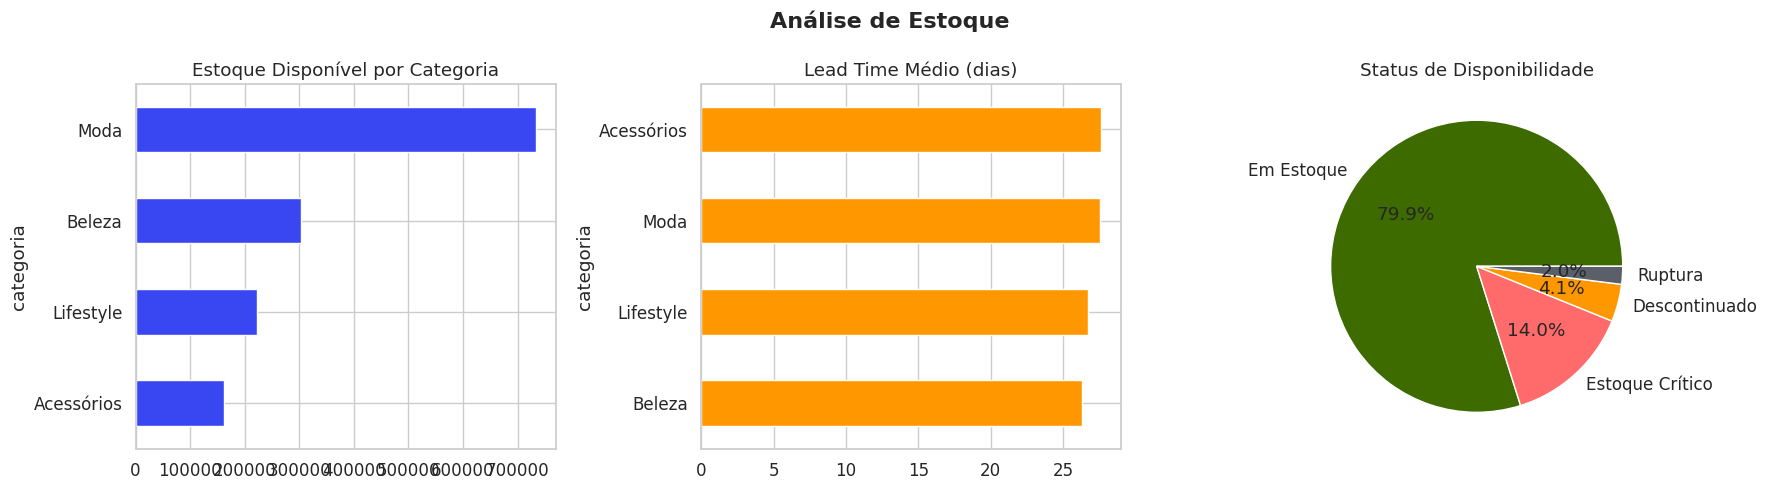

In [24]:
# 7.1 — Visão geral do estoque
print(f"📦 VISÃO GERAL DO ESTOQUE:")
print(f"   Total de SKUs:                {len(estoque):,}")
print(f"   Valor total em estoque:       R$ {(estoque['estoque_fisico'] * estoque['custo_unitario']).sum():,.2f}")
print(f"   Lead time médio (dias):       {estoque['lead_time_reposicao'].mean():.0f}")
print()

# Status de disponibilidade
print("📋 Status de Disponibilidade:")
for status, qtd in estoque['status_disponibilidade'].value_counts().items():
    print(f"   {status:25s} → {qtd:,} SKUs ({qtd/len(estoque)*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análise de Estoque', fontsize=16, fontweight='bold')

# Estoque por categoria
est_cat = estoque.groupby('categoria')['estoque_disponivel'].sum().sort_values()
est_cat.plot(kind='barh', ax=axes[0], color=COLORS['blue'])
axes[0].set_title('Estoque Disponível por Categoria')

# Lead time por categoria
lt_cat = estoque.groupby('categoria')['lead_time_reposicao'].mean().sort_values()
lt_cat.plot(kind='barh', ax=axes[1], color=COLORS['orange'])
axes[1].set_title('Lead Time Médio (dias)')

# Status
status_counts = estoque['status_disponibilidade'].value_counts()
colors_pie = [COLORS['green'], COLORS['red'], COLORS['orange'], COLORS['gray']]
status_counts.plot(kind='pie', ax=axes[2], autopct='%1.1f%%', colors=colors_pie[:len(status_counts)])
axes[2].set_title('Status de Disponibilidade')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()


In [25]:
# 7.2 — Ruptura, estoque crítico e ponto de pedido
ruptura_real = estoque[estoque['status_disponibilidade'] == 'Ruptura'].copy()
estoque_critico = estoque[estoque['status_disponibilidade'] == 'Estoque Crítico'].copy()
descontinuados = estoque[estoque['status_disponibilidade'] == 'Descontinuado'].copy()

print('⚠️ STATUS QUE EXIGEM DECISÕES DIFERENTES:')
print(f'   Ruptura real:       {len(ruptura_real):,} SKUs ({len(ruptura_real)/len(estoque)*100:.1f}%)')
print(f'   Estoque crítico:    {len(estoque_critico):,} SKUs ({len(estoque_critico)/len(estoque)*100:.1f}%)')
print(f'   Descontinuados:     {len(descontinuados):,} SKUs ({len(descontinuados)/len(estoque)*100:.1f}%)')
print('   Observação: esses grupos não devem ser somados e chamados de ruptura.\n')

estoque['abaixo_ponto_pedido'] = estoque['estoque_disponivel'] < estoque['ponto_pedido']
abaixo_pp = estoque[estoque['abaixo_ponto_pedido']]
print('🔴 SKUs ABAIXO DO PONTO DE PEDIDO:')
print(f'   Quantidade:         {len(abaixo_pp):,} SKUs')
print(f'   % do catálogo:      {len(abaixo_pp)/len(estoque)*100:.1f}%')
print('\nDistribuição por categoria:')
for cat, qtd in abaixo_pp['categoria'].value_counts().items():
    print(f'   {cat:20s} → {qtd:,} SKUs')

⚠️ STATUS QUE EXIGEM DECISÕES DIFERENTES:
   Ruptura real:       99 SKUs (2.0%)
   Estoque crítico:    701 SKUs (14.0%)
   Descontinuados:     207 SKUs (4.1%)
   Observação: esses grupos não devem ser somados e chamados de ruptura.

🔴 SKUs ABAIXO DO PONTO DE PEDIDO:
   Quantidade:         787 SKUs
   % do catálogo:      15.7%

Distribuição por categoria:
   Beleza               → 323 SKUs
   Lifestyle            → 182 SKUs
   Moda                 → 158 SKUs
   Acessórios           → 124 SKUs


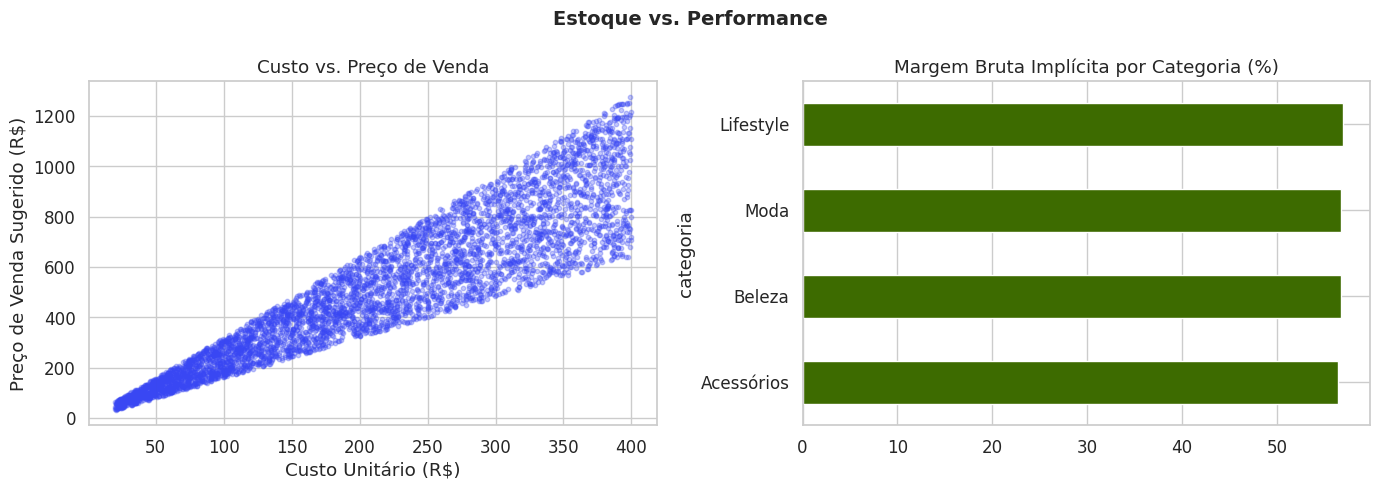

In [26]:
# 7.3 — Correlação entre estoque e performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Estoque vs. Performance', fontsize=14, fontweight='bold')

axes[0].scatter(estoque['custo_unitario'], estoque['preco_venda_sugerido'], 
                alpha=0.3, c=COLORS['blue'], s=10)
axes[0].set_xlabel('Custo Unitário (R$)')
axes[0].set_ylabel('Preço de Venda Sugerido (R$)')
axes[0].set_title('Custo vs. Preço de Venda')

# Margem implícita do estoque
estoque['margem_bruta_pct'] = ((estoque['preco_venda_sugerido'] - estoque['custo_unitario']) / estoque['preco_venda_sugerido'] * 100)
estoque.groupby('categoria')['margem_bruta_pct'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color=COLORS['green']
)
axes[1].set_title('Margem Bruta Implícita por Categoria (%)')

plt.tight_layout()
plt.show()


---
## 8. 🔗 Cruzamento entre Datasets

Análises integradas combinando vendas, clientes, atendimento e estoque para uma visão holística do negócio.


👤 CLIENTES COM vs. SEM TICKETS:


,qtd,ltv_medio,pedidos_medio
Sem Tickets,14555,9293.82,18.63
Com Tickets,445,8586.46,17.37


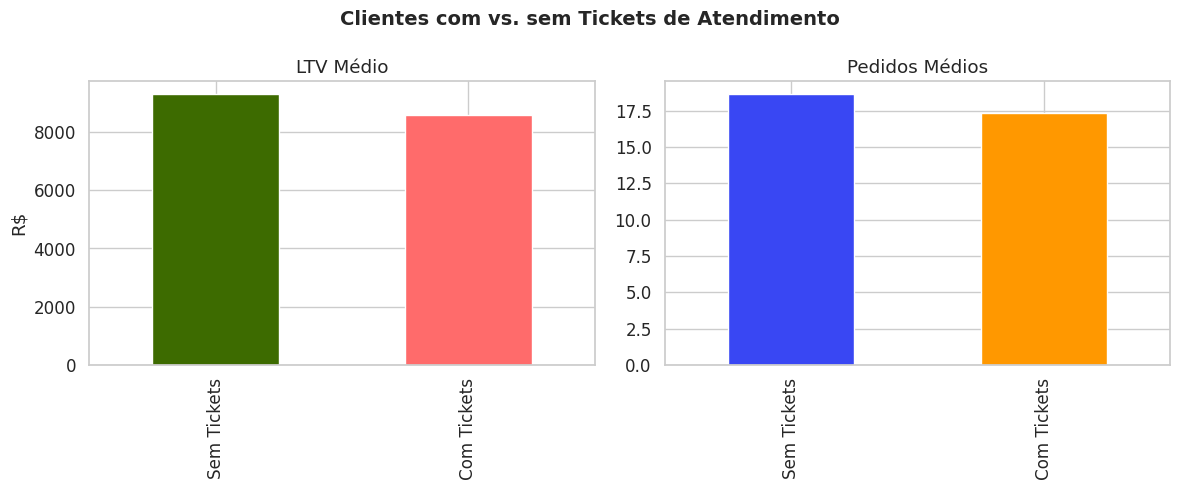

In [27]:
# 8.1 — Clientes com tickets de atendimento vs. comportamento de compra
clientes_com_tickets = atendimento['customer_id'].unique()
clientes['tem_ticket'] = clientes['customer_id'].isin(clientes_com_tickets)

print(f"👤 CLIENTES COM vs. SEM TICKETS:")
comparacao = clientes.groupby('tem_ticket').agg(
    qtd=('customer_id', 'count'),
    ltv_medio=('ltv_acumulado', 'mean'),
    pedidos_medio=('total_pedidos_historico', 'mean')
).round(2)

comparacao.index = ['Sem Tickets', 'Com Tickets']
display(comparacao)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Clientes com vs. sem Tickets de Atendimento', fontsize=14, fontweight='bold')

comparacao['ltv_medio'].plot(kind='bar', ax=axes[0], color=[COLORS['green'], COLORS['red']])
axes[0].set_title('LTV Médio')
axes[0].set_ylabel('R$')

comparacao['pedidos_medio'].plot(kind='bar', ax=axes[1], color=[COLORS['blue'], COLORS['orange']])
axes[1].set_title('Pedidos Médios')

plt.tight_layout()
plt.show()


,segmento_rfm,total_pedidos,total_devolvidos,receita_total,margem_total,desconto_medio,taxa_devolucao,margem_pct
1,Churn,145,29,112709.30,53017.36,88.048552,20.00,47.04
2,Em Risco,7430,1116,5455556.35,2735286.29,57.502758,15.02,50.14
5,Promissor,13350,1991,9865046.82,4939118.40,58.710433,14.91,50.07
4,Hibernando,632,94,454430.73,228557.25,55.830127,14.87,50.30
3,Fiel,4117,601,3049791.19,1520609.98,60.630406,14.60,49.86
0,Campeão,2084,296,1588599.45,793847.37,61.469770,14.20,49.97


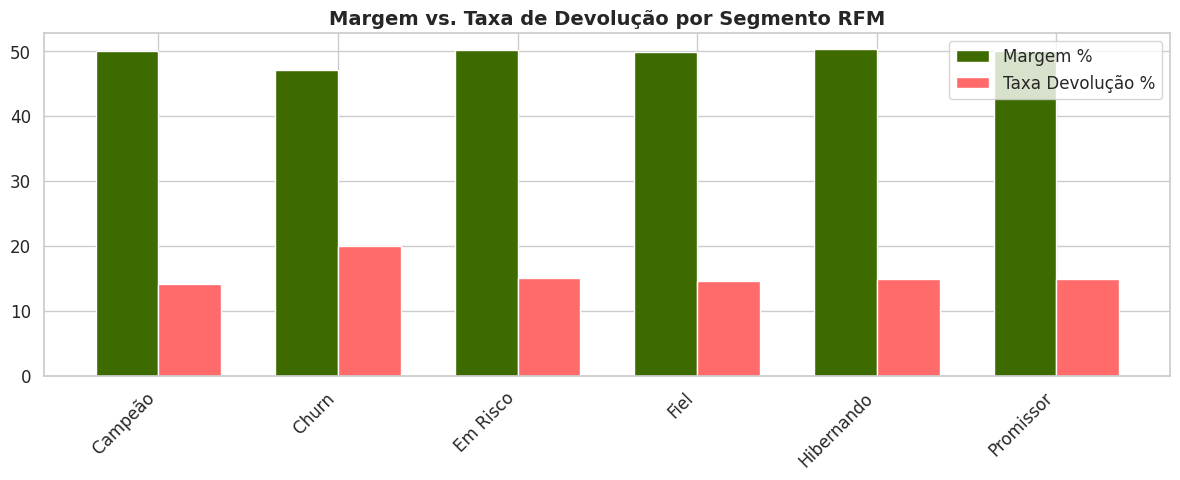

In [28]:
# 8.2 — Segmento RFM vs. Devoluções
vendas_cli = vendas.merge(clientes[['customer_id', 'segmento_rfm', 'nivel_fidelidade']], on='customer_id', how='left')

dev_por_segmento = vendas_cli.groupby('segmento_rfm').agg(
    total_pedidos=('order_id', 'count'),
    total_devolvidos=('devolvido', 'sum'),
    receita_total=('receita_bruta', 'sum'),
    margem_total=('margem_contribuicao', 'sum'),
    desconto_medio=('desconto_reais', 'mean')
).reset_index()

dev_por_segmento['taxa_devolucao'] = (dev_por_segmento['total_devolvidos'] / dev_por_segmento['total_pedidos'] * 100).round(2)
dev_por_segmento['margem_pct'] = (dev_por_segmento['margem_total'] / dev_por_segmento['receita_total'] * 100).round(2)

display(dev_por_segmento.sort_values('taxa_devolucao', ascending=False))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(dev_por_segmento))
width = 0.35
ax.bar(x - width/2, dev_por_segmento['margem_pct'], width, label='Margem %', color=COLORS['green'])
ax.bar(x + width/2, dev_por_segmento['taxa_devolucao'], width, label='Taxa Devolução %', color=COLORS['red'])
ax.set_xticks(x)
ax.set_xticklabels(dev_por_segmento['segmento_rfm'], rotation=45, ha='right')
ax.legend()
ax.set_title('Margem vs. Taxa de Devolução por Segmento RFM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


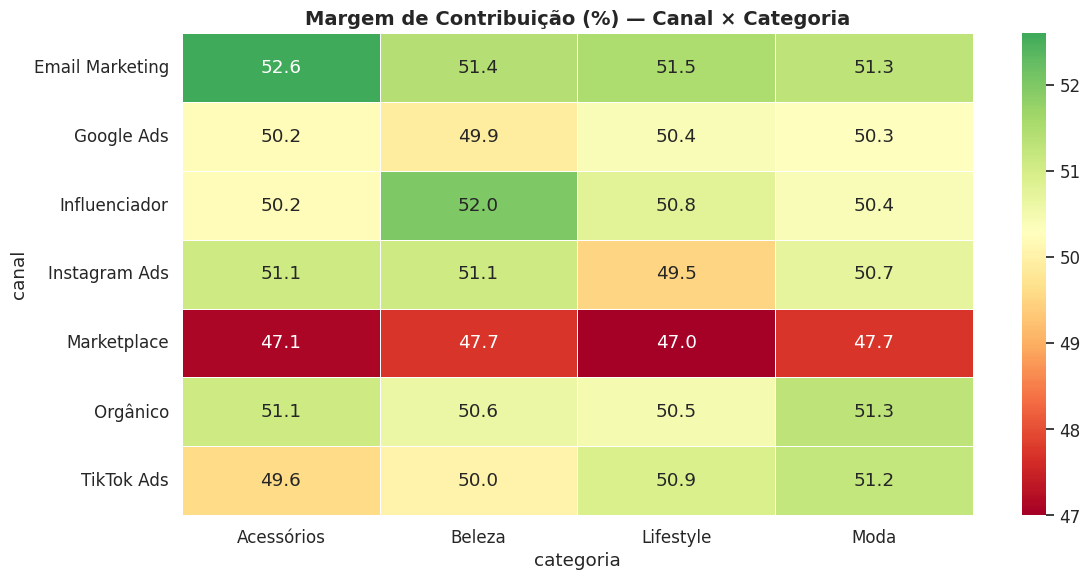

💡 Células vermelhas indicam combinações canal×categoria que destroem margem.
   Células verdes indicam combinações altamente rentáveis.


In [29]:
# 8.3 — Heatmap: Canal de Venda vs. Categoria (Margem %)
pivot_margem = vendas.pivot_table(
    values='margem_contribuicao', 
    index='canal', 
    columns='categoria', 
    aggfunc='sum'
)

pivot_receita = vendas.pivot_table(
    values='receita_bruta', 
    index='canal', 
    columns='categoria', 
    aggfunc='sum'
)

pivot_margem_pct = (pivot_margem / pivot_receita * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_margem_pct, annot=True, fmt='.1f', cmap='RdYlGn', center=pivot_margem_pct.values.mean(),
            linewidths=0.5, ax=ax)
ax.set_title('Margem de Contribuição (%) — Canal × Categoria', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 Células vermelhas indicam combinações canal×categoria que destroem margem.")
print("   Células verdes indicam combinações altamente rentáveis.")


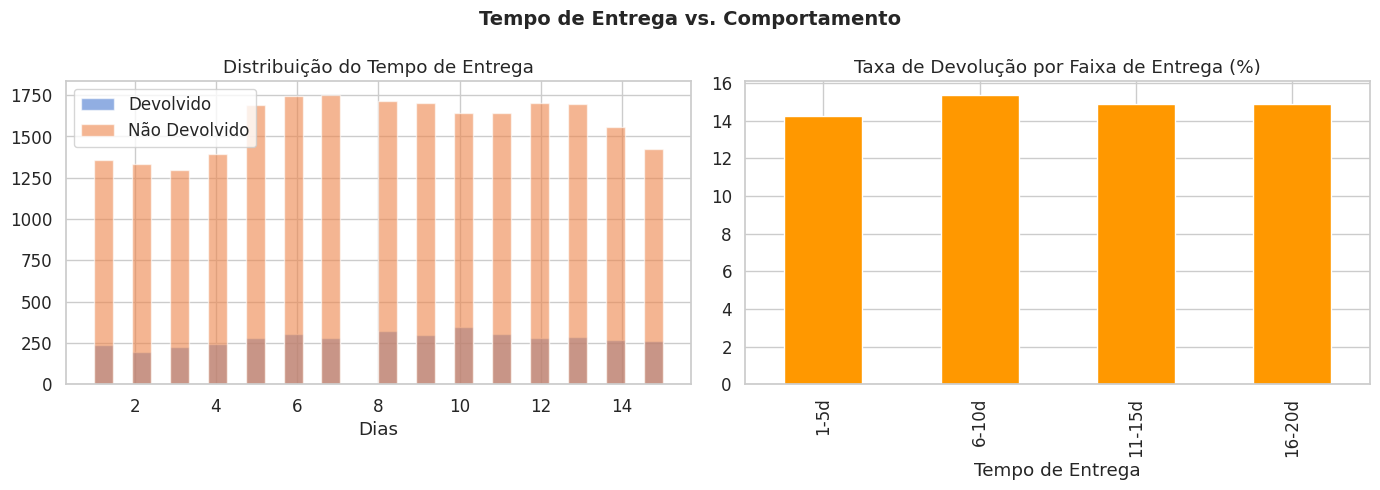


Taxa de devolução por faixa de entrega:


,devolução_pct
faixa_entrega,
1-5d,14.27
6-10d,15.35
11-15d,14.87
16-20d,14.91


Conclusão: não há crescimento monotônico da devolução conforme aumenta o prazo de entrega; associação não implica causalidade.


In [30]:
# 8.4 — Relação entre Tempo de Entrega e Devoluções
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tempo de Entrega vs. Comportamento', fontsize=14, fontweight='bold')

vendas_dev = vendas.copy()
vendas_dev['devolvido_label'] = vendas_dev['devolvido'].map({1: 'Devolvido', 0: 'Não Devolvido'})
for label, group in vendas_dev.groupby('devolvido_label'):
    group['tempo_entrega_real'].clip(upper=group['tempo_entrega_real'].quantile(0.95)).hist(
        bins=30, ax=axes[0], alpha=0.6, label=label
    )
axes[0].legend()
axes[0].set_title('Distribuição do Tempo de Entrega')
axes[0].set_xlabel('Dias')

vendas['faixa_entrega'] = pd.cut(
    vendas['tempo_entrega_real'], bins=[0, 5, 10, 15, 20, 30, 100],
    labels=['1-5d', '6-10d', '11-15d', '16-20d', '21-30d', '30d+']
)
dev_por_faixa = vendas.groupby('faixa_entrega', observed=True)['devolvido'].mean() * 100
dev_por_faixa.plot(kind='bar', ax=axes[1], color=COLORS['orange'])
axes[1].set_title('Taxa de Devolução por Faixa de Entrega (%)')
axes[1].set_xlabel('Tempo de Entrega')
plt.tight_layout()
plt.show()

print('\nTaxa de devolução por faixa de entrega:')
display(dev_por_faixa.round(2).rename('devolução_pct').to_frame())
print('Conclusão: não há crescimento monotônico da devolução conforme aumenta o prazo de entrega; associação não implica causalidade.')

---
## 9. 🧠 Síntese de Hipóteses

### Hipóteses do Case para Validação

Com base nas análises acima, vamos sintetizar quais hipóteses do case foram **validadas**, **refutadas** ou se surgiram **novas descobertas**.


In [31]:
# 9.1 — Consolidação quantitativa das hipóteses
print('=' * 70)
print('📊 CONSOLIDAÇÃO QUANTITATIVA DAS HIPÓTESES')
print('=' * 70)

margem_geral = vendas['margem_contribuicao'].sum() / vendas['receita_bruta'].sum() * 100
desconto_geral = vendas['desconto_reais'].sum() / vendas['receita_bruta'].sum() * 100
taxa_dev_geral = vendas['devolvido'].mean() * 100
investimento_total = marketing['investimento_reais'].sum()
receita_mkt = marketing['receita_gerada'].sum()
roas_geral = receita_mkt / investimento_total
custo_atend_total = atendimento['custo_operacional_ticket'].sum()
cobertura_clientes_vendas = clientes['customer_id'].isin(vendas['customer_id']).mean() * 100
cobertura_tickets_pedidos = atendimento['order_id'].isin(vendas['order_id']).mean() * 100

print(f'''\n📌 H1 — QUALIDADE DA MARGEM
   Margem de contribuição geral:    {margem_geral:.1f}%
   Desconto médio sobre receita:    {desconto_geral:.1f}%
   Taxa de devolução geral:         {taxa_dev_geral:.1f}%
   Pedidos com margem negativa:     {vendas['margem_negativa'].mean()*100:.1f}%
   Leitura: não há evidência suficiente de queda estrutural; há vazamentos concentrados.
''')

print(f'''📌 H2 — EFICIÊNCIA DE MARKETING
   Investimento total:              R$ {investimento_total:,.0f}
   Receita gerada na própria base: R$ {receita_mkt:,.0f}
   ROAS agregado:                   {roas_geral:.2f}
   Limitação: sem campanha → pedido → cliente, não é possível atribuir margem ou LTV.
''')

print(f'''📌 H3 — FALHAS OPERACIONAIS
   Receita bruta associada a devoluções: R$ {devolucoes['receita_bruta'].sum():,.0f}
   Rupturas reais:                       {len(ruptura_real):,}
   Estoque crítico:                      {len(estoque_critico):,}
   SKUs abaixo do ponto de pedido:       {estoque['abaixo_ponto_pedido'].sum():,}
''')

print(f'''📌 H4 — ATENDIMENTO E AUTOMAÇÃO
   Volume total de tickets:         {len(atendimento):,}
   Custo total observado:           R$ {custo_atend_total:,.0f}
   CSAT médio:                      {atendimento['nota_csat'].mean():.2f}
   Tickets CSAT ≤ 2:               {(atendimento['nota_csat'] <= 2).sum():,} ({(atendimento['nota_csat'] <= 2).mean()*100:.1f}%)
   Tempo médio 1ª resposta:        {atendimento['tempo_primeira_resposta_minutos'].mean():.0f} min
''')

print(f'''📌 H5/H6 — CLIENTES E QUALIDADE DAS LIGAÇÕES
   Total de clientes:               {len(clientes):,}
   Clientes presentes nas vendas:  {vendas['customer_id'].nunique():,} ({cobertura_clientes_vendas:.1f}% da base)
   Tickets ligados a pedidos:      {cobertura_tickets_pedidos:.1f}%
   Limitação: cobertura insuficiente para decisões populacionais de churn/LTV.
''')

📊 CONSOLIDAÇÃO QUANTITATIVA DAS HIPÓTESES

📌 H1 — QUALIDADE DA MARGEM
   Margem de contribuição geral:    50.0%
   Desconto médio sobre receita:    8.0%
   Taxa de devolução geral:         14.9%
   Pedidos com margem negativa:     1.8%
   Leitura: não há evidência suficiente de queda estrutural; há vazamentos concentrados.

📌 H2 — EFICIÊNCIA DE MARKETING
   Investimento total:              R$ 210,414,341
   Receita gerada na própria base: R$ 878,628,710
   ROAS agregado:                   4.18
   Limitação: sem campanha → pedido → cliente, não é possível atribuir margem ou LTV.

📌 H3 — FALHAS OPERACIONAIS
   Receita bruta associada a devoluções: R$ 3,063,301
   Rupturas reais:                       99
   Estoque crítico:                      701
   SKUs abaixo do ponto de pedido:       787

📌 H4 — ATENDIMENTO E AUTOMAÇÃO
   Volume total de tickets:         35,840
   Custo total observado:           R$ 532,260
   CSAT médio:                      3.24
   Tickets CSAT ≤ 2:               7

### Tabela de Validação de Hipóteses

| # | Hipótese | Status | Evidência e interpretação |
|---|---|---|---|
| H1 | O crescimento vem com pior qualidade de margem | 🟡 **Inconclusiva** | Margem geral de 50,04%; a oscilação temporal não comprova queda estrutural. Marketplace possui vazamento concentrado de frete. |
| H2 | Nem todo canal de aquisição gera clientes igualmente valiosos | ⚪ **Não verificável** | Há diferenças de ROAS dentro da base de marketing, mas falta campanha → pedido → cliente para comparar margem e LTV. |
| H3 | Falhas operacionais destroem valor pós-venda | 🟢 **Suportada com limitações** | Devoluções atingem 14,87%; 99 SKUs estão realmente em ruptura. O impacto líquido depende de custos não disponíveis. |
| H4 | Atendimento concentra sintomas recorrentes | 🟢 **Suportada** | “Onde está meu pedido?”, defeito e troca de tamanho concentram volume e custo; automação continua sendo cenário, não economia validada. |
| H5 | Existem diferenças relevantes entre segmentos | ⚪ **Não verificável para decisão** | O cadastro possui segmentos distintos, mas apenas 346 de 15 mil clientes aparecem nas vendas e há concentração extrema. |
| H6 | A informação fragmentada dificulta a decisão | 🟢 **Suportada** | Períodos incompatíveis, cobertura parcial dos joins e ausência de atribuição limitam análises integradas. |

> Os status foram consolidados após a revisão metodológica registrada em `analise_dados_v2.ipynb`.

---
## 10. 🚀 Próximos Passos & Recomendações para Solução com IA

### Oportunidades identificadas após validação

| Módulo | Recomendação | Situação atual | Papel da IA |
|---|---|---|---|
| **A — Funil & Canais** | Monitorar campanhas dentro da base de marketing | **Go limitado**; otimização por margem/LTV bloqueada sem atribuição | Explicar anomalias, sem realocar orçamento automaticamente |
| **B — Atendimento** | Autoatendimento e comunicação proativa para temas repetitivos | **Go condicional por regras**; classificador ML bloqueado pelo corpus repetido | Redigir e resumir, enquanto regras determinam a ação |
| **C — Priorizador de Margem** | Ranquear frete, devoluções e atendimento por evidência, confiança e prazo | **Go para o MVP** | Investigar e explicar; cálculos permanecem determinísticos |
| **D — Relatório Automático** | Gerar resumo semanal com fatos, cenários, limitações e plano | **Go condicional** com evidências rastreáveis e fallback | Síntese e crítica metodológica |

### Análises e dados adicionais recomendados

1. Criar a ligação `campanha_id → order_id → customer_id` antes de otimizar marketing.
2. Registrar reembolso, recuperação do produto e logística reversa para calcular margem pós-devolução.
3. Coletar textos reais e diversos antes de treinar classificação de tickets.
4. Manter snapshots históricos de estoque e ao menos 24 meses de demanda antes de prever demanda.
5. Medir elasticidade e conversão antes de transformar o cenário de frete em business case realizado.

### Business case preliminar

- **Marketplace:** cenário teórico de recuperação ao aproximar sua margem da média geral; exige teste de política de frete.
- **Devoluções:** oportunidade relevante, mas expressa inicialmente como receita bruta associada e cenários de recuperação.
- **Atendimento:** redução potencial de custo deve usar premissas explícitas de contenção e parcela evitável.
- **Marketing e estoque:** manter como monitoramento; não automatizar decisões avançadas com os dados atuais.

In [32]:
# 10.1 — Resumo executivo final
print('=' * 70)
print('📋 RESUMO EXECUTIVO — ANÁLISE EXPLORATÓRIA CORRIGIDA')
print('=' * 70)

print(f'''\n🏢 VÉRTICE RETAIL — DIAGNÓSTICO BASEADO EM DADOS

📊 BASE UTILIZÁVEL:
   • {len(vendas):,} registros de vendas
   • {len(marketing):,} campanhas de marketing
   • {len(clientes):,} clientes cadastrados
   • {len(atendimento):,} tickets de atendimento
   • {len(estoque):,} SKUs em catálogo

💰 INDICADORES OBSERVADOS:
   • Receita bruta total:        R$ {vendas['receita_bruta'].sum():>12,.0f}
   • Margem de contribuição:     {margem_geral:.1f}%
   • Taxa de devolução:          {taxa_dev_geral:.1f}%
   • ROAS na base de marketing: {roas_geral:.2f}x
   • CSAT médio:                 {atendimento['nota_csat'].mean():.1f}
   • Rupturas reais:             {len(ruptura_real):,} SKUs

🎯 CONCLUSÃO PARA O MVP:
   1. Priorizar qualidade dos dados antes das recomendações.
   2. Usar diagnóstico determinístico para frete, devoluções e atendimento.
   3. Permitir simulação com premissas explícitas.
   4. Gerar relatório executivo auditável e plano 30–60–90.
   5. Bloquear ML e otimizações sem dados suficientes.
''')

📋 RESUMO EXECUTIVO — ANÁLISE EXPLORATÓRIA CORRIGIDA

🏢 VÉRTICE RETAIL — DIAGNÓSTICO BASEADO EM DADOS

📊 BASE UTILIZÁVEL:
   • 27,758 registros de vendas
   • 3,500 campanhas de marketing
   • 15,000 clientes cadastrados
   • 35,840 tickets de atendimento
   • 5,000 SKUs em catálogo

💰 INDICADORES OBSERVADOS:
   • Receita bruta total:        R$   20,526,134
   • Margem de contribuição:     50.0%
   • Taxa de devolução:          14.9%
   • ROAS na base de marketing: 4.18x
   • CSAT médio:                 3.2
   • Rupturas reais:             99 SKUs

🎯 CONCLUSÃO PARA O MVP:
   1. Priorizar qualidade dos dados antes das recomendações.
   2. Usar diagnóstico determinístico para frete, devoluções e atendimento.
   3. Permitir simulação com premissas explícitas.
   4. Gerar relatório executivo auditável e plano 30–60–90.
   5. Bloquear ML e otimizações sem dados suficientes.

